# 📊 Analyse exploratoire — Tribunal judiciaire

**Source :** fichier JSONL `database-judilibre/Tribunal judiciaire`  
**Volume :** volume à déterminer  
**Approche :** lecture streaming ligne par ligne — rien n'est chargé intégralement en mémoire.

---

## Plan d'analyse

| # | Section | Objectif |
|---|---------|----------|
| 1 | **Setup** | Imports, chemin du fichier, utilitaires de lecture streaming |
| 2 | **Profiling du schéma** | Types, taux de remplissage, cardinalité par champ |
| 3 | **Champs catégoriels** | Distribution des valeurs discrètes (juridiction, chambre, solution…) |
| 4 | **Champs temporels** | Distribution dans le temps (dates de décision, mise à jour) |
| 5 | **Champs textuels** | Longueurs, distribution, thèmes fréquents |
| 6 | **Champs structurés** | Listes et dicts imbriqués (contested, rapprochements, zones…) |
| 7 | **Synthèse** | Tableau qualité, points d'attention, prochaines étapes |

## 1. Setup & Configuration

In [1]:
import json
import os
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# ── Chemin ──────────────────────────────────────────────────────────────────
FILE_PATH = Path("database-judilibre/Tribunal judiciaire")

print(f"Fichier : {FILE_PATH}")
print(f"Taille  : {FILE_PATH.stat().st_size / 1e9:.2f} Go")

# ── Utilitaire de lecture streaming ─────────────────────────────────────────
def iter_records(path: Path, max_records: int | None = None):
    """Génère les enregistrements JSON un par un sans tout charger en mémoire."""
    with open(path, "r", encoding="utf-8") as fh:
        for i, line in enumerate(fh):
            if max_records is not None and i >= max_records:
                break
            line = line.strip()
            if line:
                yield json.loads(line)

# Comptage rapide du nombre de lignes
with open(FILE_PATH, "r", encoding="utf-8") as fh:
    N_TOTAL = sum(1 for _ in fh)
print(f"Nombre de décisions : {N_TOTAL:,}")

Fichier : database-judilibre/Tribunal judiciaire
Taille  : 1.87 Go
Nombre de décisions : 142,239


---
## 2. Profiling du schéma

Une **seule passe** sur le fichier pour collecter :
- le(s) **type(s) Python** observé(s) par champ
- le **taux de remplissage** (valeur non-`None`, non-vide)
- le **nombre de valeurs distinctes** (cardinalité) pour les champs à faible cardinalité

La passe sera aussi utilisée pour collecter les compteurs des sections suivantes.

In [2]:
from collections import defaultdict, Counter

# ── Structures d'accumulation ────────────────────────────────────────────────

# Profiling schéma
field_types      = defaultdict(Counter)   # champ → {type_name: count}
field_filled     = Counter()              # champ → nb enregistrements où le champ est "rempli"
field_seen       = Counter()              # champ → nb enregistrements où le champ existe

# Champs catégoriels (valeurs à faible cardinalité)
CAT_FIELDS = [
    "jurisdiction", "type", "solution", "solution_alt",
    "chamber", "formation", "bulletin", "nac",
    "particularInterest", "partial", "to_be_deleted",
]
cat_counters = {f: Counter() for f in CAT_FIELDS}

# Publication : liste de strings → on explose les valeurs
pub_counter = Counter()

# Champs liste → distribution de longueur
LIST_FIELDS = ["publication", "files", "numbers", "rapprochements",
               "visa", "themes", "zones", "timeline"]
list_len_counters = {f: Counter() for f in LIST_FIELDS}

# Champs textuels → longueurs en nb de caractères
TEXT_FIELDS = ["text", "summary", "titlesAndSummaries"]
text_lengths = {f: [] for f in TEXT_FIELDS}   # liste limitée pour histogrammes

# Thèmes (liste de strings)
themes_counter = Counter()

# Dates temporelles
date_year_counters = {f: Counter() for f in
                      ["decision_date", "update_date", "decision_datetime", "update_datetime"]}

# Champs dict imbriqués → sous-clés présentes
DICT_FIELDS = ["contested", "forward"]
dict_subkeys = {f: Counter() for f in DICT_FIELDS}

# ── Passe unique ─────────────────────────────────────────────────────────────
MAX_TEXT_SAMPLES = 200_000   # on plafonne les listes de longueurs pour la mémoire

for rec in iter_records(FILE_PATH):
    for field, value in rec.items():
        field_seen[field] += 1
        field_types[field][type(value).__name__] += 1

        # Remplissage : None / liste vide / string vide → non rempli
        if value is None:
            pass
        elif isinstance(value, (list, dict)) and len(value) == 0:
            pass
        elif isinstance(value, str) and value.strip() in ("", "[]", "{}"):
            pass
        else:
            field_filled[field] += 1

        # Catégoriels
        if field in CAT_FIELDS:
            cat_counters[field][value] += 1

        # Publication (liste de strings)
        if field == "publication" and isinstance(value, list):
            for item in value:
                if isinstance(item, str):
                    pub_counter[item] += 1

        # Listes
        if field in LIST_FIELDS and isinstance(value, list):
            list_len_counters[field][len(value)] += 1

        # Textes
        if field in TEXT_FIELDS:
            if isinstance(value, str) and value.strip() not in ("", "[]", "{}"):
                if len(text_lengths[field]) < MAX_TEXT_SAMPLES:
                    text_lengths[field].append(len(value))

        # Thèmes
        if field == "themes" and isinstance(value, list):
            for t in value:
                if isinstance(t, str):
                    themes_counter[t.strip().lower()] += 1

        # Dates
        if field in date_year_counters and isinstance(value, str) and len(value) >= 4:
            date_year_counters[field][value[:4]] += 1

        # Dicts imbriqués
        if field in DICT_FIELDS and isinstance(value, dict):
            for sk, sv in value.items():
                if sv is not None:
                    dict_subkeys[field][sk] += 1

print("✅ Passe terminée.")

✅ Passe terminée.


In [3]:
# ── Tableau de profiling du schéma ──────────────────────────────────────────
rows = []
for field in sorted(field_seen.keys()):
    n_seen   = field_seen[field]
    n_filled = field_filled[field]
    fill_pct = n_filled / N_TOTAL * 100
    types    = ", ".join(f"{t}({c:,})" for t, c in field_types[field].most_common())
    rows.append({
        "Champ":           field,
        "Présent (n)":     n_seen,
        "Rempli (n)":      n_filled,
        "Taux remplissage": f"{fill_pct:.1f}%",
        "Types observés":  types,
    })

df_schema = pd.DataFrame(rows).sort_values("Taux remplissage", ascending=False)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 50)
df_schema

,Champ,Présent (n),Rempli (n),Taux remplissage,Types observés
33,zones,142239,141673,99.6%,"dict(141,673), NoneType(566)"
12,location,142239,142239,100.0%,"str(142,239)"
31,update_datetime,142239,142239,100.0%,"str(142,239)"
30,update_date,142239,142239,100.0%,"str(142,239)"
29,type,142239,142239,100.0%,"str(142,239)"
23,text,142239,142230,100.0%,"str(142,239)"
20,solution,142239,142239,100.0%,"str(142,239)"
1,chamber,142239,142239,100.0%,"str(142,239)"
16,partial,142239,142239,100.0%,"bool(142,239)"
15,numbers,142239,142239,100.0%,"list(142,239)"


---
## 3. Champs catégoriels

Distribution des valeurs pour : `type`, `solution`, `chamber`, `formation`, `publication`, `bulletin`, `nac`, `particularInterest`, `partial`.

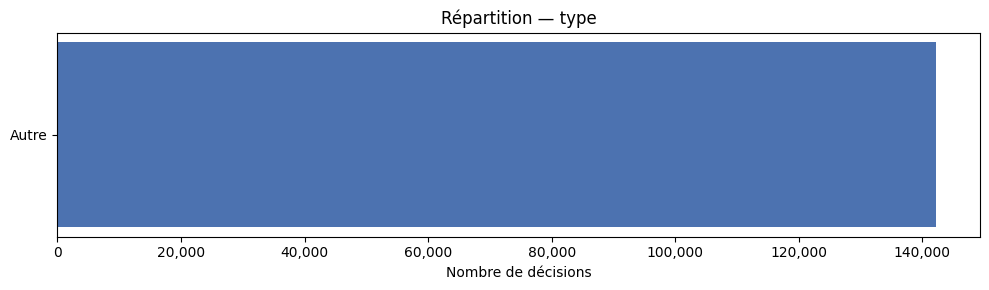

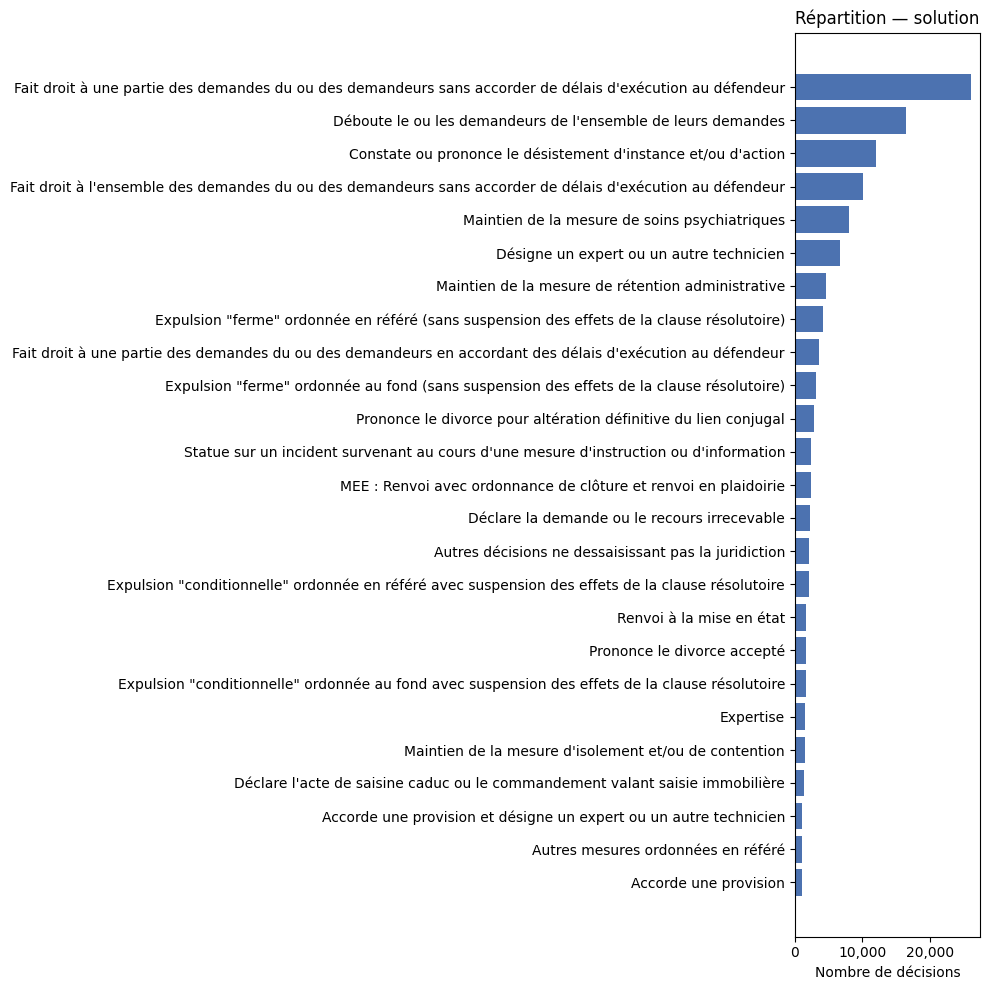

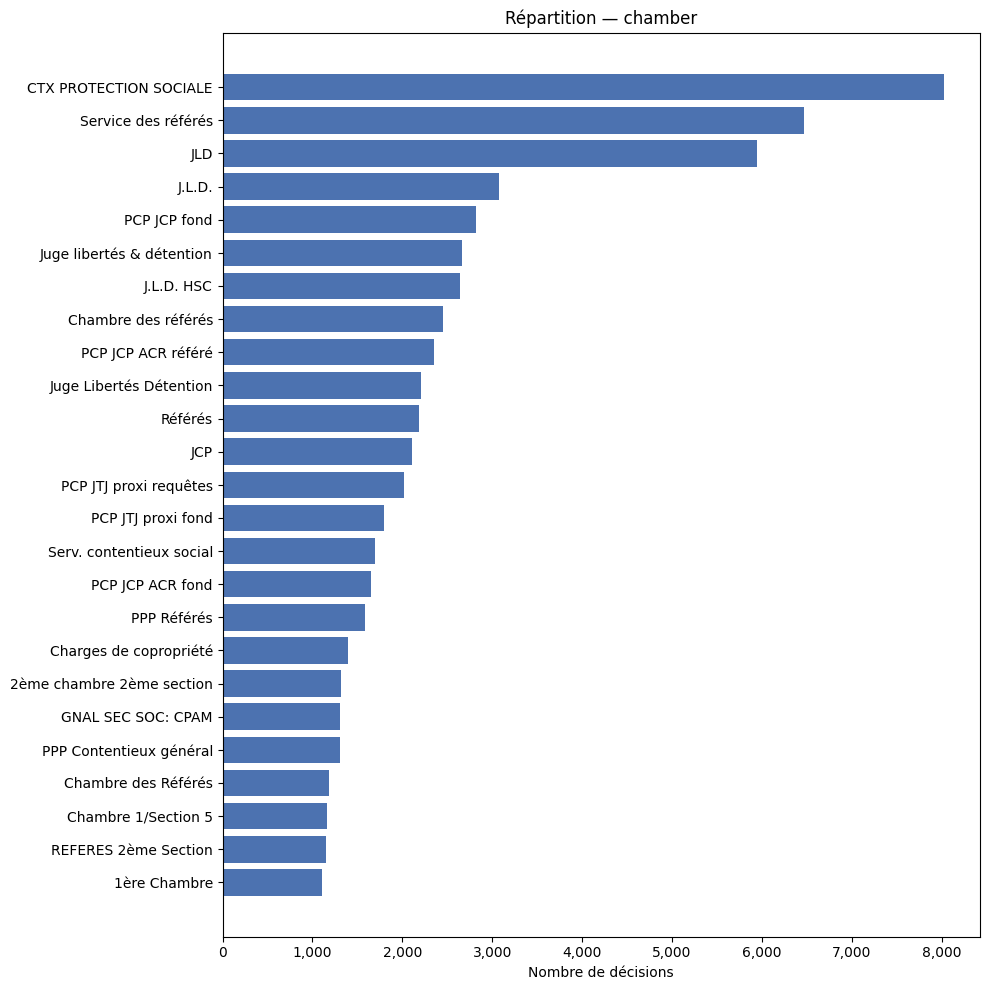

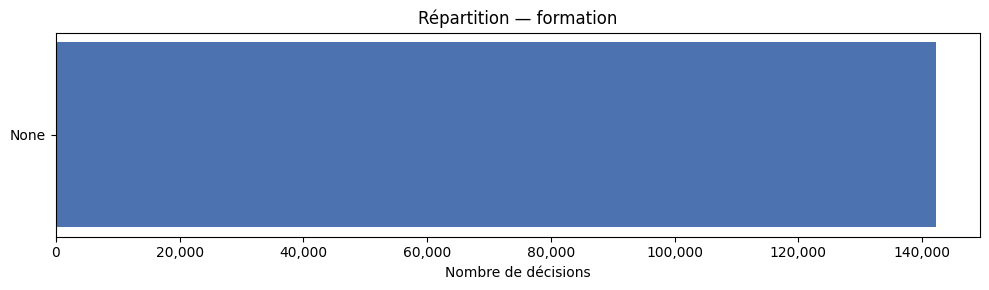

In [4]:
def plot_cat(counter: Counter, title: str, top_n: int = 20, ax=None):
    """Barplot horizontal d'un Counter."""
    data = counter.most_common(top_n)
    labels = [str(k) for k, _ in data]
    values = [v for _, v in data]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.35)))
    ax.barh(labels[::-1], values[::-1], color="#4C72B0")
    ax.set_xlabel("Nombre de décisions")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()

# Champs à afficher individuellement
for field in ["type", "solution", "chamber", "formation"]:
    if cat_counters[field]:
        fig, ax = plt.subplots(figsize=(10, max(3, min(25, len(cat_counters[field])) * 0.4)))
        plot_cat(cat_counters[field], f"Répartition — {field}", top_n=25, ax=ax)
        plt.show()

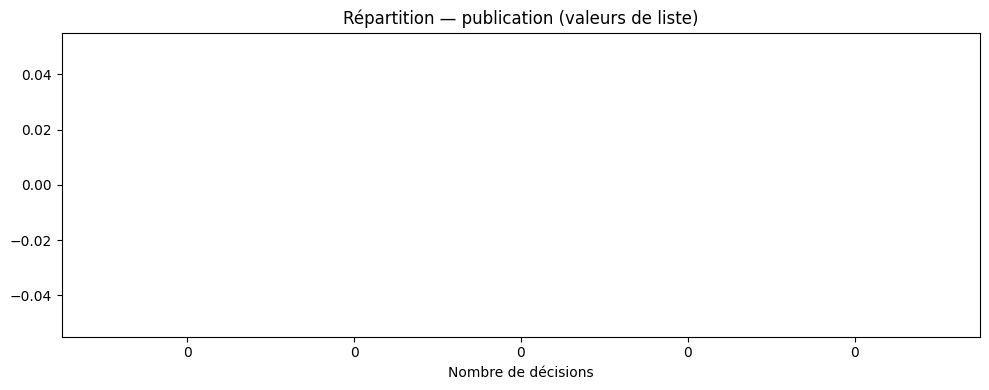

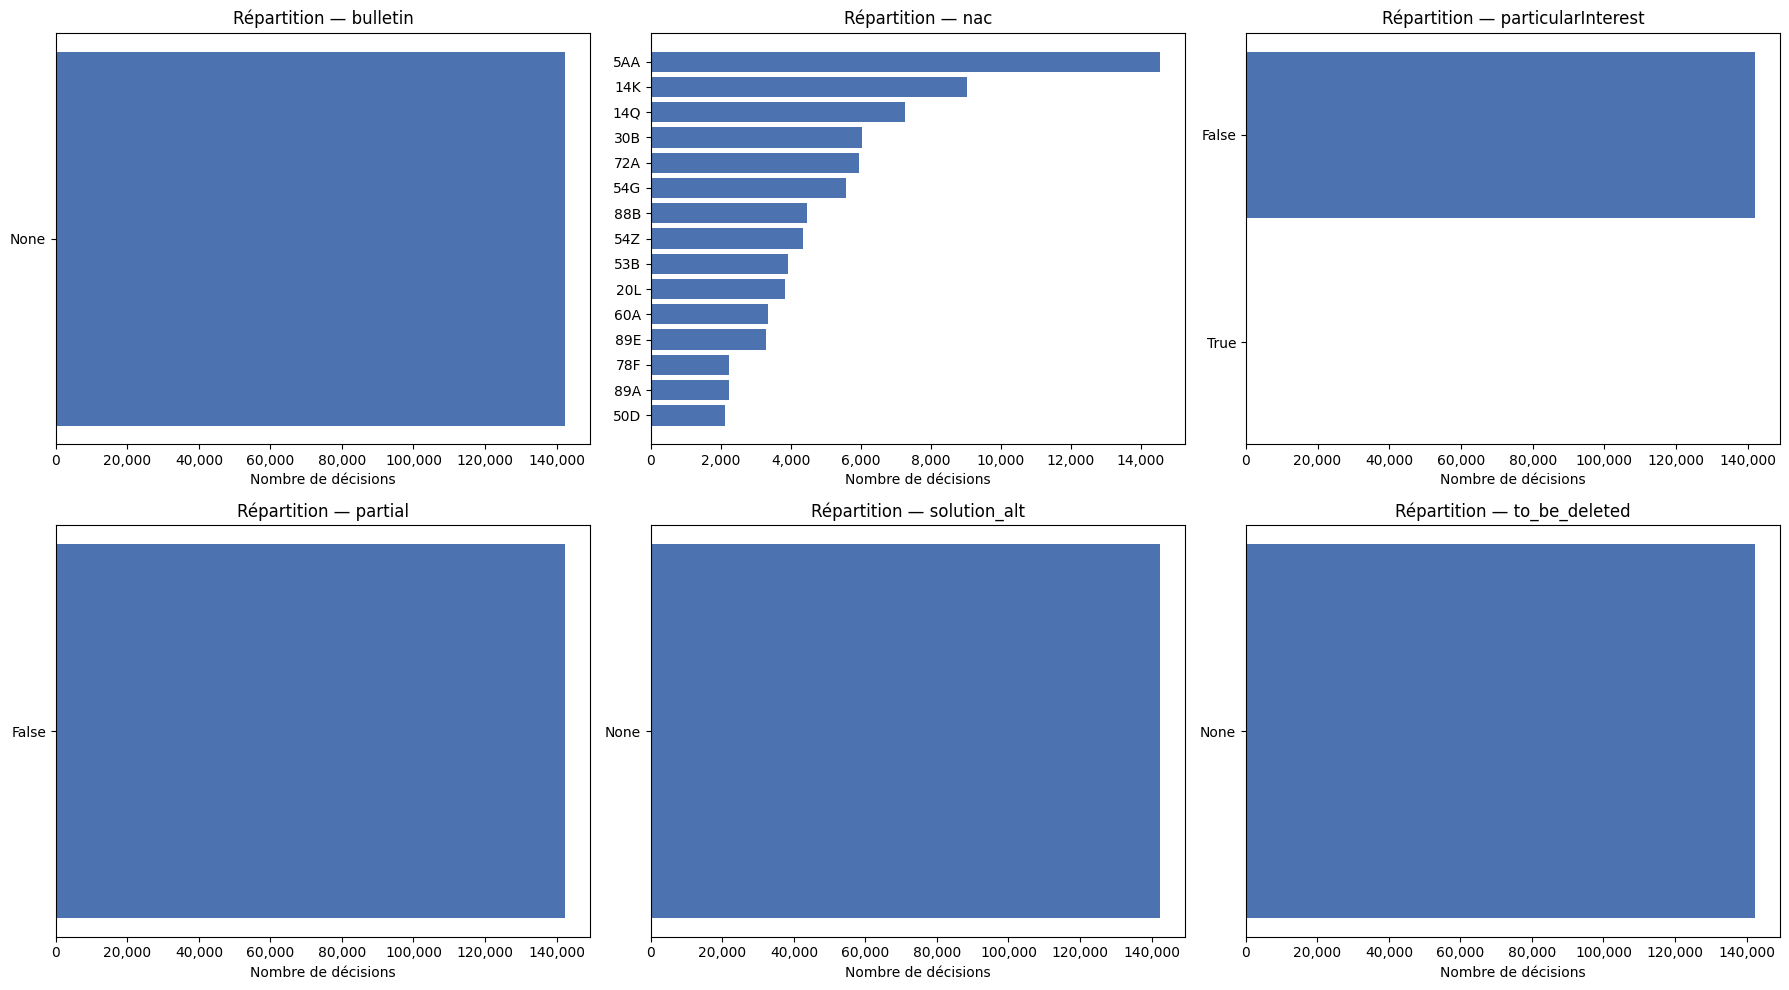


────────────────────────────────────────────────────────────
  TYPE
────────────────────────────────────────────────────────────
Valeur  Nb décisions  % du total
 Autre        142239       100.0

────────────────────────────────────────────────────────────
  SOLUTION
────────────────────────────────────────────────────────────
                                                                                                    Valeur  Nb décisions  % du total
Fait droit à une partie des demandes du ou des demandeurs sans accorder de délais d'exécution au défendeur         26108       18.36
                                              Déboute le ou les demandeurs de l'ensemble de leurs demandes         16490       11.59
                                             Constate ou prononce le désistement d'instance et/ou d'action         11988        8.43
Fait droit à l'ensemble des demandes du ou des demandeurs sans accorder de délais d'exécution au défendeur         10038        7.06
     

In [5]:
# ── Publication (valeurs explosées depuis les listes) ───────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
plot_cat(pub_counter, "Répartition — publication (valeurs de liste)", top_n=20, ax=ax)
plt.show()

# ── Petits champs catégoriels ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
small_cats = ["bulletin", "nac", "particularInterest", "partial", "solution_alt", "to_be_deleted"]
for ax, field in zip(axes.flat, small_cats):
    c = cat_counters[field]
    if c:
        plot_cat(c, f"Répartition — {field}", top_n=15, ax=ax)
    else:
        ax.set_title(f"{field} — (vide / non collecté)")
        ax.axis("off")
plt.tight_layout()
plt.show()

# ── Tableaux récap ───────────────────────────────────────────────────────────
for field in ["type", "solution", "chamber", "formation"]:
    df = pd.DataFrame(
        cat_counters[field].most_common(30), columns=["Valeur", "Nb décisions"]
    )
    df["% du total"] = (df["Nb décisions"] / N_TOTAL * 100).round(2)
    print(f"\n{'─'*60}\n  {field.upper()}\n{'─'*60}")
    print(df.to_string(index=False))

---
## 4. Champs temporels

Distribution par année pour `decision_date`, `update_date`, `decision_datetime`, `update_datetime`.

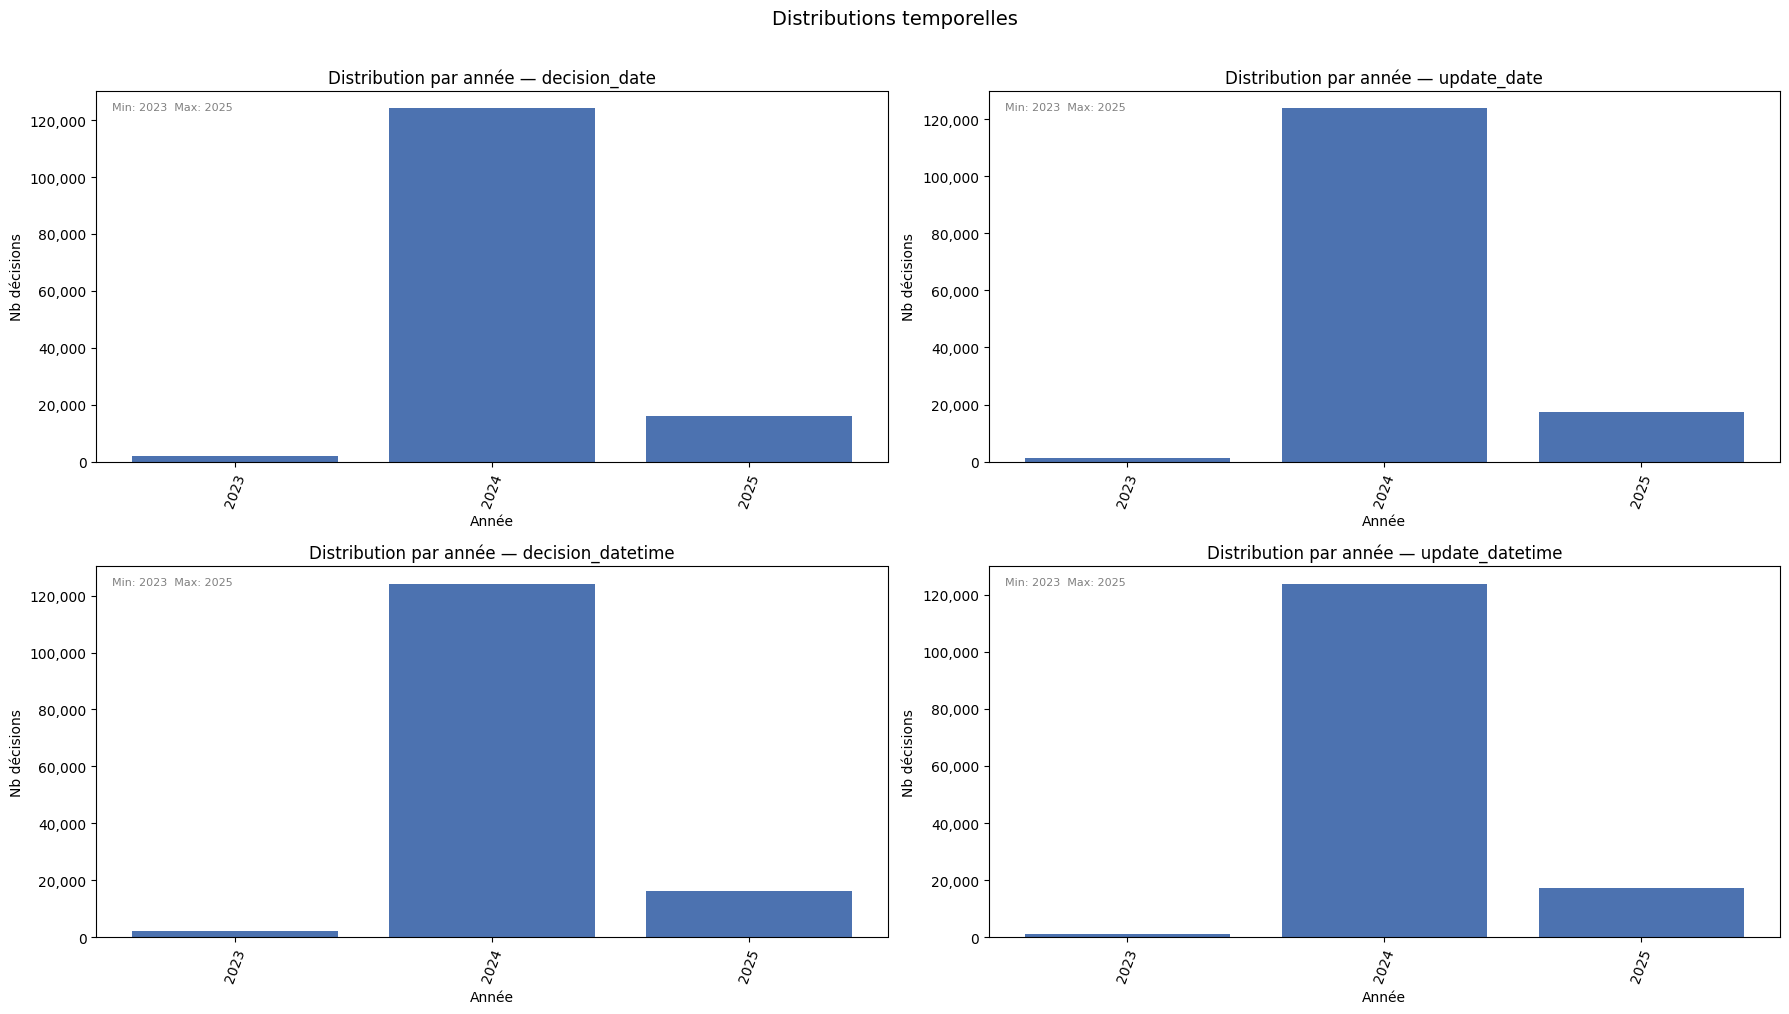


DECISION_DATE — top 20 années

Année  Nb décisions  % du total
 2024        124114       87.26
 2025         16081       11.31
 2023          2044        1.44

UPDATE_DATE — top 20 années

Année  Nb décisions  % du total
 2024        123811       87.04
 2025         17312       12.17
 2023          1116        0.78


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, field in zip(axes.flat, ["decision_date", "update_date", "decision_datetime", "update_datetime"]):
    c = date_year_counters[field]
    if not c:
        ax.set_title(f"{field} — (aucune donnée)")
        ax.axis("off")
        continue
    years  = sorted(c.keys())
    counts = [c[y] for y in years]
    ax.bar(years, counts, color="#4C72B0", width=0.8)
    ax.set_title(f"Distribution par année — {field}")
    ax.set_xlabel("Année")
    ax.set_ylabel("Nb décisions")
    ax.tick_params(axis="x", rotation=70)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    # Annotations min / max / médiane
    if years:
        ax.text(0.02, 0.97, f"Min: {years[0]}  Max: {years[-1]}",
                transform=ax.transAxes, va="top", fontsize=8, color="gray")

plt.suptitle("Distributions temporelles", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Résumé tabulaire
for field in ["decision_date", "update_date"]:
    c = date_year_counters[field]
    if c:
        df_t = pd.DataFrame(sorted(c.items()), columns=["Année", "Nb décisions"])
        df_t["% du total"] = (df_t["Nb décisions"] / N_TOTAL * 100).round(2)
        print(f"\n{field.upper()} — top 20 années\n")
        print(df_t.sort_values("Nb décisions", ascending=False).head(20).to_string(index=False))

---
## 5. Champs textuels

Distribution des longueurs (en caractères) pour `text`, `summary`, `titlesAndSummaries`, et top thèmes.

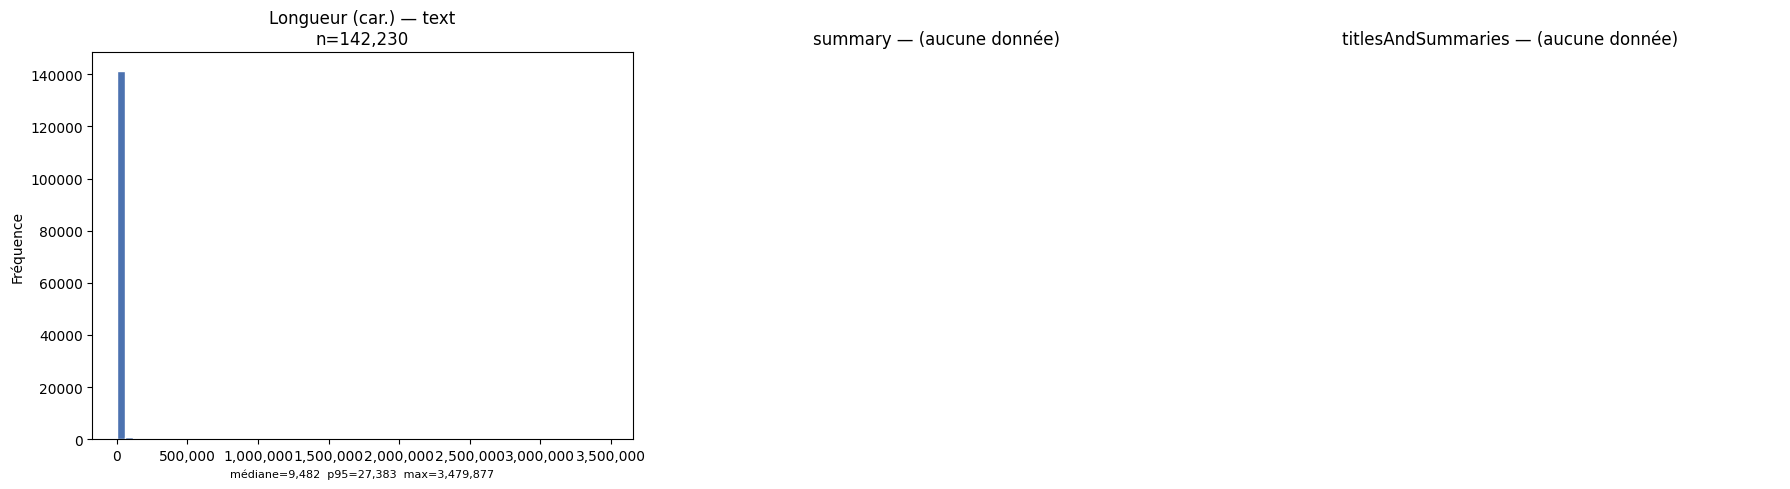


── Statistiques longueurs textes ──

text (n=142,230)
  min     :          483 car.
  p25     :        5,671 car.
  médiane :        9,482 car.
  moyenne :       11,459 car.
  p75     :       14,350 car.
  p95     :       27,383 car.
  p99     :       48,524 car.
  max     :    3,479,877 car.


In [7]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, field in zip(axes, TEXT_FIELDS):
    lengths = text_lengths[field]
    if not lengths:
        ax.set_title(f"{field} — (aucune donnée)")
        ax.axis("off")
        continue
    arr = np.array(lengths)
    ax.hist(arr, bins=60, color="#4C72B0", edgecolor="white")
    ax.set_title(f"Longueur (car.) — {field}\nn={len(arr):,}")
    ax.set_xlabel("Nb caractères")
    ax.set_ylabel("Fréquence")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    # Stats
    stats = (f"médiane={np.median(arr):,.0f}  "
             f"p95={np.percentile(arr, 95):,.0f}  "
             f"max={arr.max():,}")
    ax.set_xlabel(stats, fontsize=8)

plt.tight_layout()
plt.show()

# Statistiques descriptives
print("\n── Statistiques longueurs textes ──")
for field in TEXT_FIELDS:
    lengths = text_lengths[field]
    if lengths:
        arr = np.array(lengths)
        print(f"\n{field} (n={len(arr):,})")
        for label, val in [
            ("min",    arr.min()),
            ("p25",    np.percentile(arr, 25)),
            ("médiane",np.median(arr)),
            ("moyenne",arr.mean()),
            ("p75",    np.percentile(arr, 75)),
            ("p95",    np.percentile(arr, 95)),
            ("p99",    np.percentile(arr, 99)),
            ("max",    arr.max()),
        ]:
            print(f"  {label:8s}: {val:>12,.0f} car.")

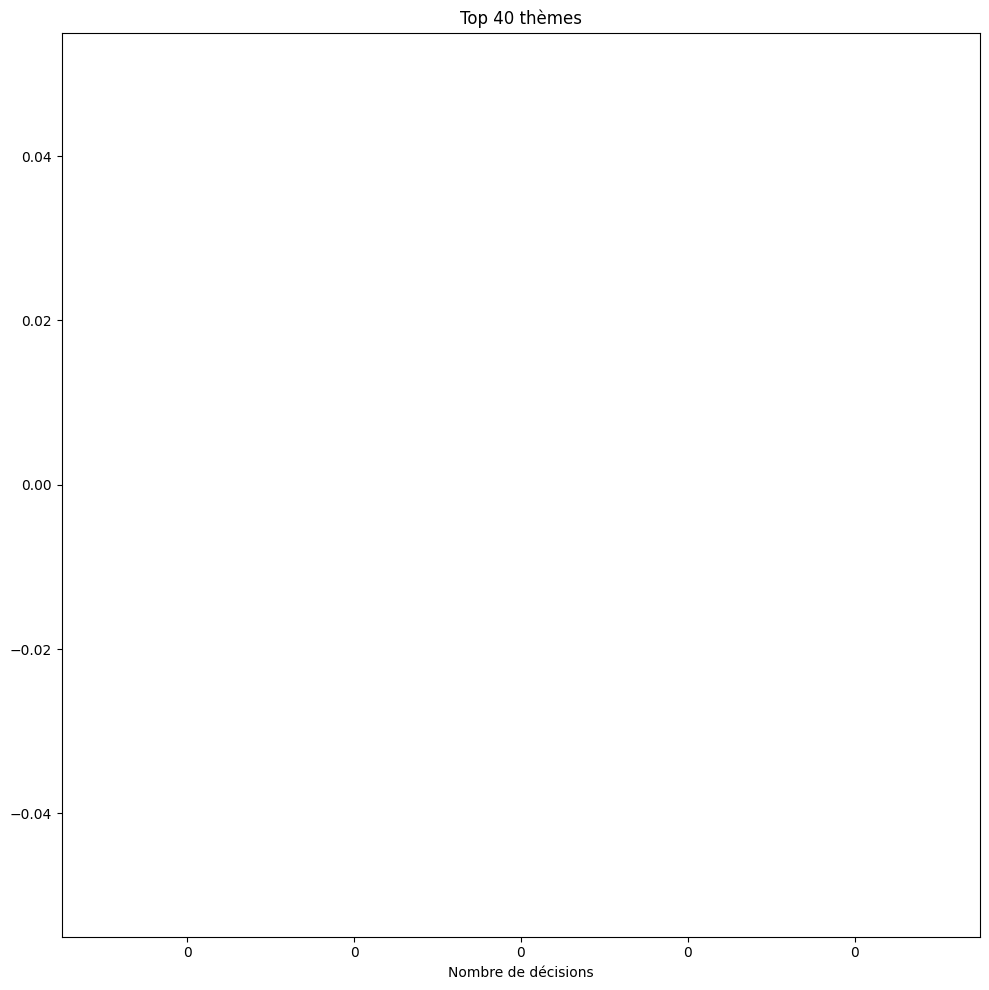

TypeError: Expected numeric dtype, got object instead.

In [8]:
# ── Top thèmes ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
plot_cat(themes_counter, "Top 40 thèmes", top_n=40, ax=ax)
plt.show()

df_themes = pd.DataFrame(themes_counter.most_common(50), columns=["Thème", "Nb occurrences"])
df_themes["% décisions"] = (df_themes["Nb occurrences"] / N_TOTAL * 100).round(2)
print(f"\nNombre de thèmes distincts : {len(themes_counter):,}")
df_themes.head(50)

---
## 6. Champs structurés (listes & dicts)

- **Listes** : `publication`, `files`, `numbers`, `rapprochements`, `visa`, `themes`, `zones`, `timeline` → distribution des longueurs
- **Dicts** : `contested`, `forward` → présence des sous-clés

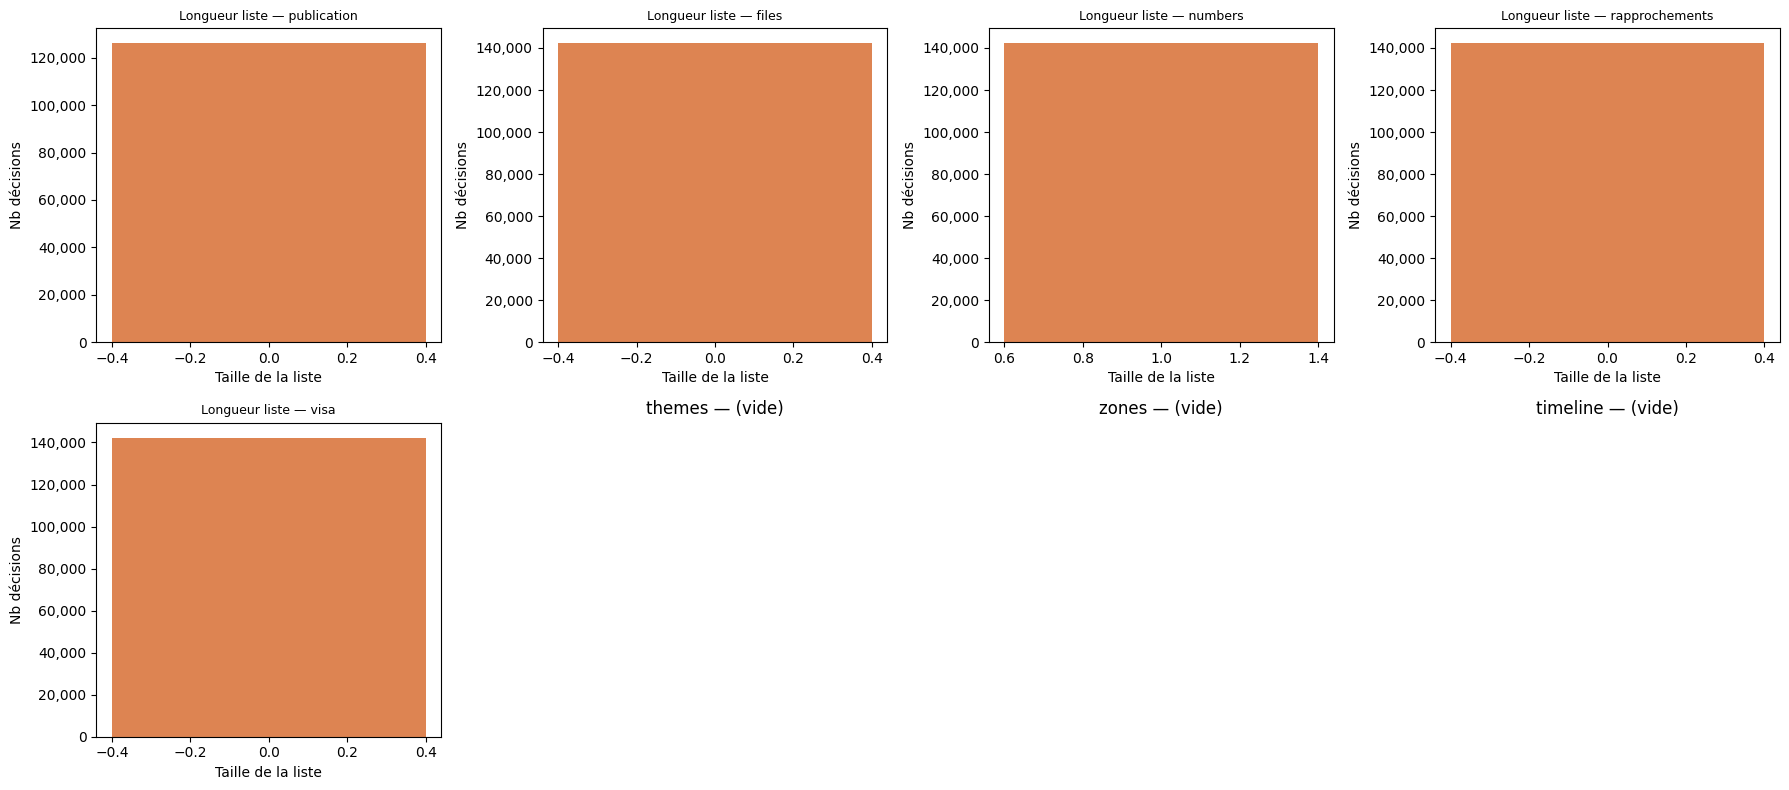


── contested : aucun enregistrement enrichi

── forward : aucun enregistrement enrichi


In [9]:
# ── Distribution des longueurs de listes ────────────────────────────────────
n_list_fields = len(LIST_FIELDS)
n_cols = 4
n_rows = (n_list_fields + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flat

for ax, field in zip(axes, LIST_FIELDS):
    c = list_len_counters[field]
    if not c:
        ax.set_title(f"{field} — (vide)")
        ax.axis("off")
        continue
    lens   = sorted(c.keys())
    counts = [c[l] for l in lens]
    # On plafonne l'affichage à longueur ≤ 20 pour lisibilité
    lens_disp   = [l for l in lens if l <= 20]
    counts_disp = [c[l] for l in lens_disp]
    ax.bar(lens_disp, counts_disp, color="#DD8452")
    n_gt20 = sum(c[l] for l in lens if l > 20)
    title_suffix = f" (+{n_gt20:,} avec len>20)" if n_gt20 else ""
    ax.set_title(f"Longueur liste — {field}{title_suffix}", fontsize=9)
    ax.set_xlabel("Taille de la liste")
    ax.set_ylabel("Nb décisions")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Cacher les axes vides
for ax in list(axes):
    if not ax.has_data():
        ax.axis("off")

plt.tight_layout()
plt.show()

# ── Sous-clés des champs dict ────────────────────────────────────────────────
for field in DICT_FIELDS:
    c = dict_subkeys[field]
    if c:
        df_d = pd.DataFrame(c.most_common(), columns=["Sous-clé", "Nb présences non-null"])
        df_d["% décisions"] = (df_d["Nb présences non-null"] / N_TOTAL * 100).round(2)
        print(f"\n── {field} ──")
        print(df_d.to_string(index=False))
    else:
        print(f"\n── {field} : aucun enregistrement enrichi")

---
## 7. Synthèse qualité des données

In [10]:
# ── Tableau récapitulatif qualité ────────────────────────────────────────────
rows_synth = []
for field in sorted(field_seen.keys()):
    fill_pct  = field_filled[field] / N_TOTAL * 100
    n_types   = len(field_types[field])
    type_list = ", ".join(field_types[field].keys())

    if fill_pct >= 90:
        quality = "🟢 Bien rempli"
    elif fill_pct >= 50:
        quality = "🟡 Partiellement rempli"
    elif fill_pct > 0:
        quality = "🟠 Peu rempli"
    else:
        quality = "🔴 Vide / nul"

    rows_synth.append({
        "Champ":              field,
        "Taux remplissage":   f"{fill_pct:.1f}%",
        "Nb types distincts": n_types,
        "Types":              type_list,
        "Qualité":            quality,
    })

df_synth = pd.DataFrame(rows_synth).sort_values("Taux remplissage", ascending=False)
print(f"Total décisions analysées : {N_TOTAL:,}\n")
df_synth

Total décisions analysées : 142,239



,Champ,Taux remplissage,Nb types distincts,Types,Qualité
33,zones,99.6%,2,"dict, NoneType",🟢 Bien rempli
12,location,100.0%,1,str,🟢 Bien rempli
31,update_datetime,100.0%,1,str,🟢 Bien rempli
30,update_date,100.0%,1,str,🟢 Bien rempli
29,type,100.0%,1,str,🟢 Bien rempli
23,text,100.0%,1,str,🟢 Bien rempli
20,solution,100.0%,1,str,🟢 Bien rempli
1,chamber,100.0%,1,str,🟢 Bien rempli
16,partial,100.0%,1,bool,🟢 Bien rempli
15,numbers,100.0%,1,list,🟢 Bien rempli


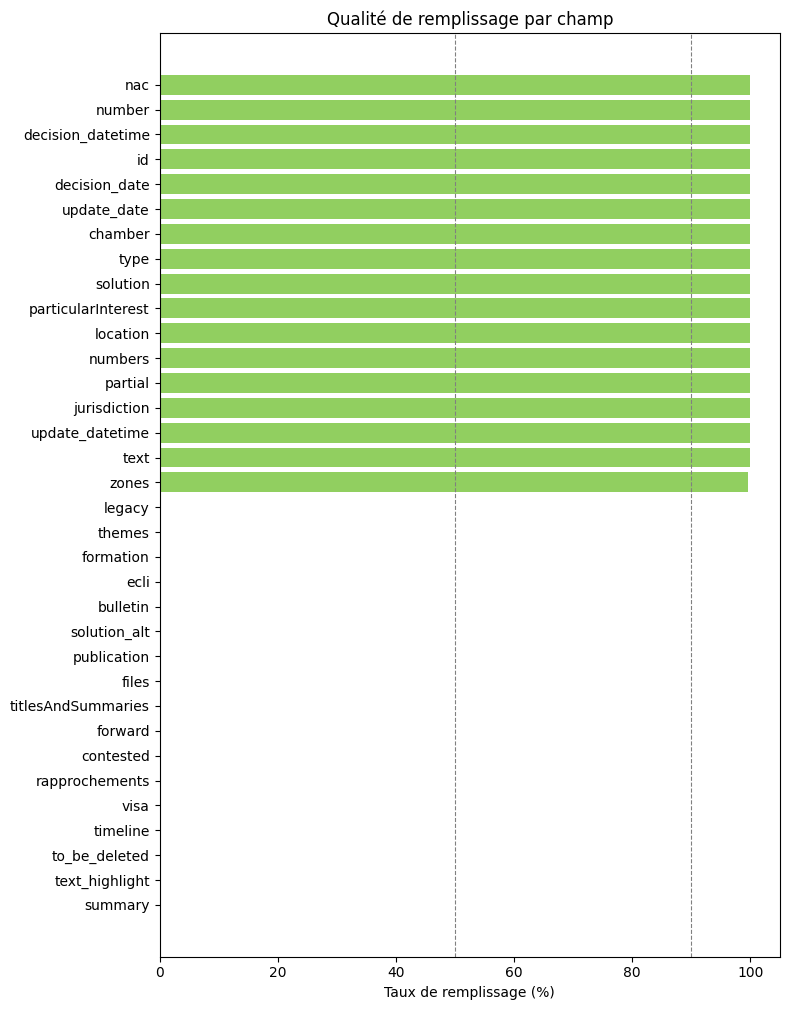

In [11]:
# ── Heatmap des taux de remplissage ─────────────────────────────────────────
fill_series = pd.Series(
    {field: field_filled[field] / N_TOTAL * 100 for field in field_seen},
    name="Taux remplissage (%)"
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, len(fill_series) * 0.3)))
colors = ["#d73027" if v < 10 else "#fc8d59" if v < 50 else "#fee090" if v < 90 else "#91cf60"
          for v in fill_series]
ax.barh(fill_series.index, fill_series.values, color=colors)
ax.set_xlabel("Taux de remplissage (%)")
ax.set_title("Qualité de remplissage par champ")
ax.axvline(50,  color="gray", linestyle="--", linewidth=0.8)
ax.axvline(90,  color="gray", linestyle="--", linewidth=0.8)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

---
## 8. Analyse de corrélation — `has_visa` vs autres features

On construit un DataFrame binaire/numérique par décision (une passe streaming) puis on calcule les corrélations de **`has_visa`** (la décision contient au moins un visa) avec les autres variables.

In [12]:
# ── Passe streaming : collecte de features par décision ─────────────────────
import numpy as np

# On collecte des features binaires et numériques par enregistrement
features_rows = []

for rec in iter_records(FILE_PATH):
    visa = rec.get("visa", [])
    has_visa = isinstance(visa, list) and len(visa) > 0

    themes = rec.get("themes", [])
    has_themes = isinstance(themes, list) and len(themes) > 0

    summary = rec.get("summary", "")
    has_summary = isinstance(summary, str) and summary.strip() not in ("", "[]", "{}")

    rappr = rec.get("rapprochements", [])
    has_rapprochements = isinstance(rappr, list) and len(rappr) > 0

    zones = rec.get("zones", [])
    has_zones = isinstance(zones, list) and len(zones) > 0

    timeline = rec.get("timeline", [])
    has_timeline = isinstance(timeline, list) and len(timeline) > 0

    files = rec.get("files", [])
    has_files = isinstance(files, list) and len(files) > 0

    titles = rec.get("titlesAndSummaries", "")
    has_titlesAndSummaries = isinstance(titles, str) and titles.strip() not in ("", "[]", "{}")

    contested = rec.get("contested", {})
    has_contested = isinstance(contested, dict) and len(contested) > 0

    forward = rec.get("forward", {})
    has_forward = isinstance(forward, dict) and len(forward) > 0

    text = rec.get("text", "")
    text_len = len(text) if isinstance(text, str) else 0

    # Nombre de visa
    n_visa = len(visa) if isinstance(visa, list) else 0

    # Solution (top catégories)
    solution = rec.get("solution", None)
    chamber = rec.get("chamber", None)
    rec_type = rec.get("type", None)
    bulletin = rec.get("bulletin", None)
    particular = rec.get("particularInterest", None)

    # Année de décision
    dec_date = rec.get("decision_date", "")
    year = int(dec_date[:4]) if isinstance(dec_date, str) and len(dec_date) >= 4 and dec_date[:4].isdigit() else None

    # Publication
    pub = rec.get("publication", [])
    has_publication = isinstance(pub, list) and len(pub) > 0

    n_themes = len(themes) if isinstance(themes, list) else 0
    n_rappr = len(rappr) if isinstance(rappr, list) else 0

    features_rows.append({
        "has_visa":               int(has_visa),
        "n_visa":                 n_visa,
        "has_themes":             int(has_themes),
        "n_themes":               n_themes,
        "has_summary":            int(has_summary),
        "has_rapprochements":     int(has_rapprochements),
        "n_rapprochements":       n_rappr,
        "has_zones":              int(has_zones),
        "has_timeline":           int(has_timeline),
        "has_files":              int(has_files),
        "has_titlesAndSummaries": int(has_titlesAndSummaries),
        "has_contested":          int(has_contested),
        "has_forward":            int(has_forward),
        "has_publication":        int(has_publication),
        "text_length":            text_len,
        "solution":               solution,
        "chamber":                chamber,
        "type":                   rec_type,
        "bulletin":               bulletin,
        "particularInterest":     particular,
        "year":                   year,
    })

df_feat = pd.DataFrame(features_rows)
print(f"✅ DataFrame construit : {df_feat.shape[0]:,} lignes × {df_feat.shape[1]} colonnes")
df_feat.head()

✅ DataFrame construit : 142,239 lignes × 21 colonnes


,has_visa,n_visa,has_themes,n_themes,has_summary,has_rapprochements,n_rapprochements,has_zones,has_timeline,has_files,...,has_contested,has_forward,has_publication,text_length,solution,chamber,type,bulletin,particularInterest,year
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,3479877,Fait droit à une partie des demandes du ou des demandeurs en accordant des d...,9/1/1 dossiers seriels,Autre,None,False,2023
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,11480,"Expulsion ""ferme"" ordonnée en référé (sans suspension des effets de la claus...",Service des référés,Autre,None,False,2023
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,10639,Fait droit à l'ensemble des demandes du ou des demandeurs sans accorder de d...,GNAL SEC SOC : URSSAF,Autre,None,False,2023
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,6622,Déboute le ou les demandeurs de l'ensemble de leurs demandes,CTX PROTECTION SOCIALE,Autre,None,False,2023
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,13965,"Expulsion ""ferme"" ordonnée au fond (sans suspension des effets de la clause ...",PCP JCP ACR fond,Autre,None,False,2023


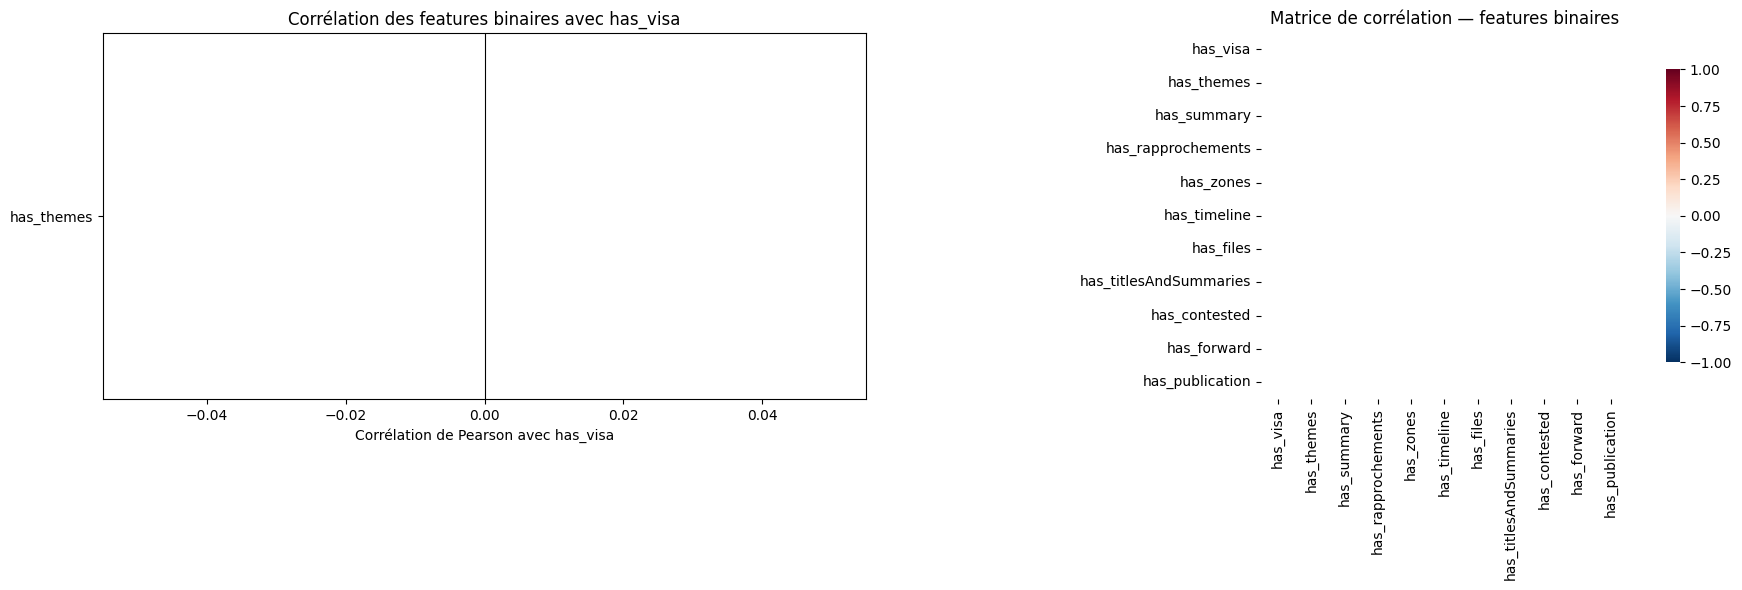


── Corrélation de has_visa avec les autres features binaires ──

               Feature  Corrélation
            has_themes          NaN
           has_summary          NaN
    has_rapprochements          NaN
             has_zones          NaN
          has_timeline          NaN
             has_files          NaN
has_titlesAndSummaries          NaN
         has_contested          NaN
           has_forward          NaN
       has_publication          NaN


In [13]:
# ── Corrélation de has_visa avec les features binaires ──────────────────────
import seaborn as sns

binary_cols = [
    "has_visa", "has_themes", "has_summary", "has_rapprochements",
    "has_zones", "has_timeline", "has_files", "has_titlesAndSummaries",
    "has_contested", "has_forward", "has_publication",
]

# Matrice de corrélation (Phi / point-biserial pour variables binaires)
corr_binary = df_feat[binary_cols].corr()

# Afficher la corrélation de has_visa avec toutes les autres
corr_visa = corr_binary["has_visa"].drop("has_visa").sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Barplot des corrélations avec has_visa
colors = ["#2ca02c" if v > 0 else "#d62728" for v in corr_visa.values]
axes[0].barh(corr_visa.index, corr_visa.values, color=colors)
axes[0].set_xlabel("Corrélation de Pearson avec has_visa")
axes[0].set_title("Corrélation des features binaires avec has_visa")
axes[0].axvline(0, color="black", linewidth=0.8)
for i, (val, name) in enumerate(zip(corr_visa.values, corr_visa.index)):
    axes[0].text(val + 0.005 if val >= 0 else val - 0.005,
                 i, f"{val:.3f}", va="center", fontsize=9,
                 ha="left" if val >= 0 else "right")

# 2. Heatmap complète
mask = np.triu(np.ones_like(corr_binary, dtype=bool), k=1)
sns.heatmap(corr_binary, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            mask=mask, square=True, linewidths=0.5, ax=axes[1],
            vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
axes[1].set_title("Matrice de corrélation — features binaires")

plt.tight_layout()
plt.show()

# Tableau récap
print("\n── Corrélation de has_visa avec les autres features binaires ──\n")
df_corr = pd.DataFrame({
    "Feature": corr_visa.index,
    "Corrélation": corr_visa.values,
    "Abs": np.abs(corr_visa.values),
}).sort_values("Abs", ascending=False).drop(columns="Abs")
print(df_corr.to_string(index=False))

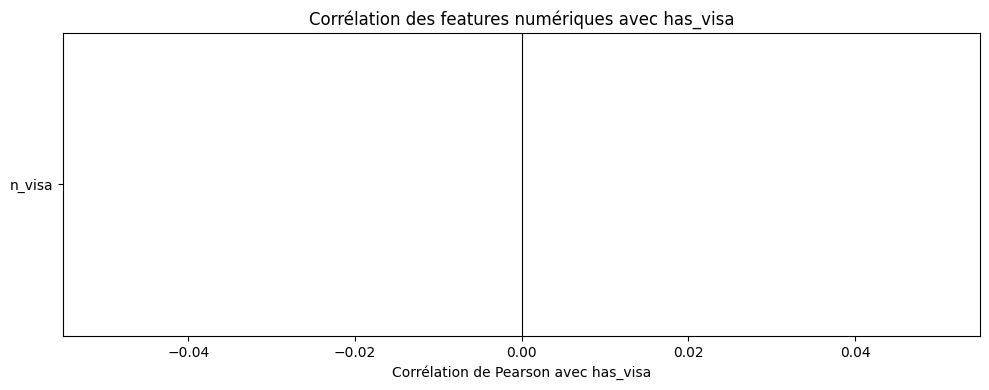

In [14]:
# ── Corrélation has_visa avec features numériques continues ─────────────────

numeric_cols = ["n_visa", "n_themes", "n_rapprochements", "text_length"]
corr_num = df_feat[["has_visa"] + numeric_cols].corr()["has_visa"].drop("has_visa").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in corr_num.values]
ax.barh(corr_num.index, corr_num.values, color=colors)
ax.set_xlabel("Corrélation de Pearson avec has_visa")
ax.set_title("Corrélation des features numériques avec has_visa")
ax.axvline(0, color="black", linewidth=0.8)
for i, (val, name) in enumerate(zip(corr_num.values, corr_num.index)):
    ax.text(val + 0.005 if val >= 0 else val - 0.005,
            i, f"{val:.3f}", va="center", fontsize=9,
            ha="left" if val >= 0 else "right")
plt.tight_layout()
plt.show()

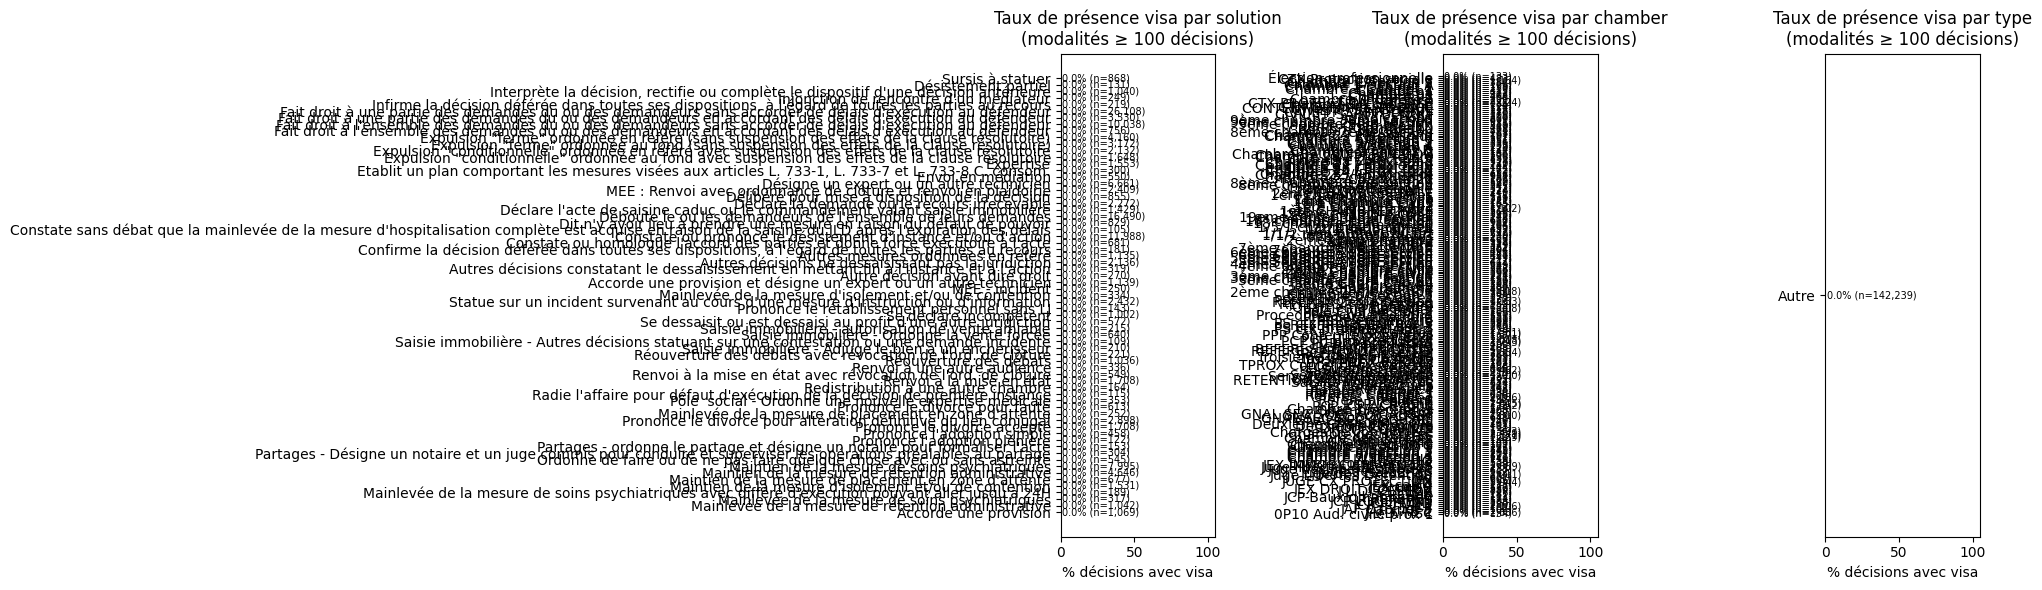

In [15]:
# ── Corrélation has_visa × catégorielles (solution, chamber, type) ──────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, cat_col in zip(axes, ["solution", "chamber", "type"]):
    # Taux de has_visa par modalité
    grp = df_feat.groupby(cat_col)["has_visa"].agg(["mean", "count"])
    grp = grp[grp["count"] >= 100]  # garder seulement les modalités avec ≥100 décisions
    grp = grp.sort_values("mean", ascending=True)

    colors = plt.cm.RdYlGn(grp["mean"].values)
    ax.barh(grp.index, grp["mean"] * 100, color=colors)
    ax.set_xlabel("% décisions avec visa")
    ax.set_title(f"Taux de présence visa par {cat_col}\n(modalités ≥ 100 décisions)")
    ax.set_xlim(0, 105)

    # Annotations
    for i, (idx, row) in enumerate(grp.iterrows()):
        ax.text(row["mean"] * 100 + 1, i,
                f'{row["mean"]*100:.1f}% (n={int(row["count"]):,})',
                va="center", fontsize=7)

plt.tight_layout()
plt.show()

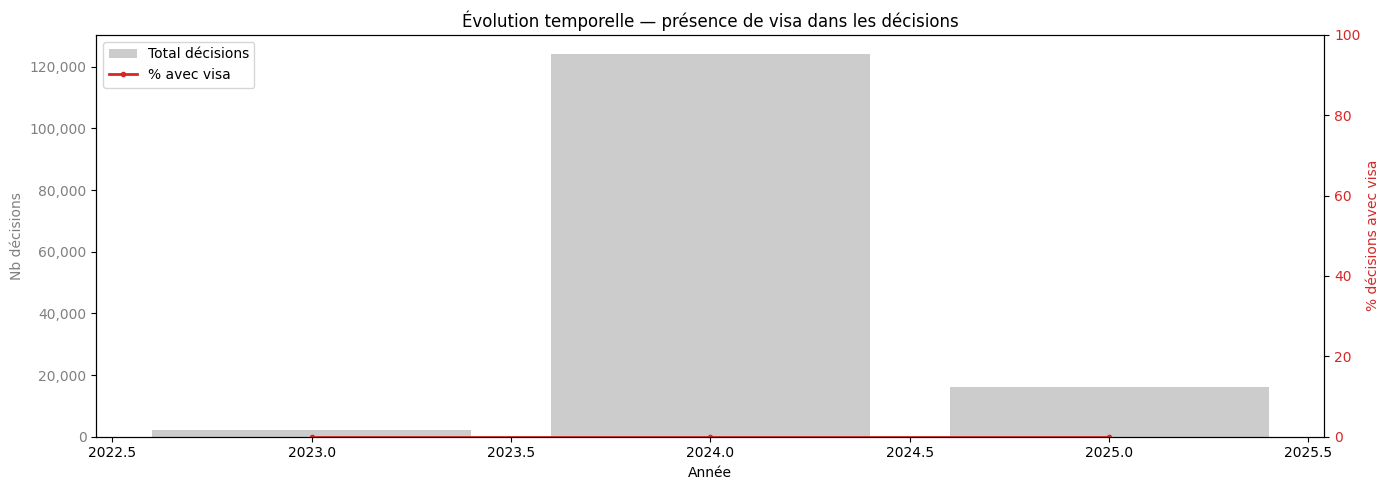


Taux global has_visa : 0.0%
Décisions avec visa  : 0 / 142,239


In [16]:
# ── Évolution temporelle de has_visa ─────────────────────────────────────────

df_year = df_feat.dropna(subset=["year"]).copy()
df_year["year"] = df_year["year"].astype(int)

grp_year = df_year.groupby("year").agg(
    n_total=("has_visa", "count"),
    n_visa=("has_visa", "sum"),
    pct_visa=("has_visa", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Barres : nb total de décisions
ax1.bar(grp_year["year"], grp_year["n_total"], color="#ccc", label="Total décisions", zorder=1)
ax1.set_xlabel("Année")
ax1.set_ylabel("Nb décisions", color="gray")
ax1.tick_params(axis="y", labelcolor="gray")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Ligne : taux de visa
ax2 = ax1.twinx()
ax2.plot(grp_year["year"], grp_year["pct_visa"] * 100, color="#d62728",
         marker="o", markersize=3, linewidth=2, label="% avec visa", zorder=2)
ax2.set_ylabel("% décisions avec visa", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
ax2.set_ylim(0, 100)

ax1.set_title("Évolution temporelle — présence de visa dans les décisions")

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

# Stats résumé
print(f"\nTaux global has_visa : {df_feat['has_visa'].mean()*100:.1f}%")
print(f"Décisions avec visa  : {df_feat['has_visa'].sum():,} / {len(df_feat):,}")

---
## Points d'attention & prochaines étapes

À compléter après exécution :
- **Champs vides** : identifier quels champs sont structurellement absents (données historiques vs récentes ?)
- **Incohérences de types** : certains champs apparaissent en `str` et `list` selon les enregistrements
- **`titlesAndSummaries` / `legacy`** : champs qui semblent stocker du JSON sérialisé en string → à parser
- **`zones`** : structure complexe imbriquée → mérite une analyse dédiée (segmentation du texte)
- **`visa`** : références légales → analyse de fréquence des textes cités
- **Analyse croisée** : solution × chambre, type × période temporelle, etc.

---
## 9. Extraction des codes juridiques et articles de loi

**Objectif :** Identifier les codes et articles cités dans les décisions par parsing regex.

**Approche :**
- Liste de référence : 67 codes officiels (OpenLegi) + variantes historiques
- 3 extracteurs : codes seuls, articles seuls, couples code+article
- Extraction depuis : texte intégral, chaque zone (intro, visa, motivations, moyens, dispositif), champ visa structuré
- Échantillon : 50 000 décisions

In [17]:
# ── Liste de référence des codes juridiques ─────────────────────────────────

CODES_OFFICIELS = [
    "Code civil",
    "Code de commerce",
    "Code de déontologie des architectes",
    "Code de justice administrative",
    "Code de justice militaire (nouveau)",
    "Code de l'action sociale et des familles",
    "Code de l'entrée et du séjour des étrangers et du droit d'asile",
    "Code de l'environnement",
    "Code de l'expropriation pour cause d'utilité publique",
    "Code de l'organisation judiciaire",
    "Code de l'urbanisme",
    "Code de l'énergie",
    "Code de la Légion d'honneur, de la Médaille militaire et de l'ordre national du Mérite",
    "Code de la commande publique",
    "Code de la consommation",
    "Code de la construction et de l'habitation",
    "Code de la défense",
    "Code de la famille et de l'aide sociale",
    "Code de la justice pénale des mineurs",
    "Code de la mutualité",
    "Code de la propriété intellectuelle",
    "Code de la route",
    "Code de la santé publique",
    "Code de la sécurité intérieure",
    "Code de la sécurité sociale",
    "Code de la voirie routière",
    "Code de procédure civile",
    "Code de procédure pénale",
    "Code des assurances",
    "Code des communes",
    "Code des communes de la Nouvelle-Calédonie",
    "Code des douanes",
    "Code des douanes de Mayotte",
    "Code des impositions sur les biens et services",
    "Code des instruments monétaires et des médailles",
    "Code des juridictions financières",
    "Code des pensions civiles et militaires de retraite",
    "Code des pensions de retraite des marins français du commerce, de pêche ou de plaisance",
    "Code des pensions militaires d'invalidité et des victimes de guerre",
    "Code des ports maritimes",
    "Code des postes et des communications électroniques",
    "Code des procédures civiles d'exécution",
    "Code des relations entre le public et l'administration",
    "Code disciplinaire et pénal de la marine marchande",
    "Code du cinéma et de l'image animée",
    "Code du domaine de l'Etat",
    "Code du domaine de l'Etat et des collectivités publiques applicable à la collectivité territoriale de Mayotte",
    "Code du domaine public fluvial et de la navigation intérieure",
    "Code du patrimoine",
    "Code du service national",
    "Code du sport",
    "Code du travail",
    "Code du travail maritime",
    "Code forestier (nouveau)",
    "Code général de la fonction publique",
    "Code général de la propriété des personnes publiques",
    "Code général des collectivités territoriales",
    "Code général des impôts",
    "Code général des impôts, annexe IV",
    "Code minier (nouveau)",
    "Code monétaire et financier",
    "Code pénal",
    "Code pénitentiaire",
    "Code rural (ancien)",
    "Code rural et de la pêche maritime",
    "Code électoral",
    "Livre des procédures fiscales",
]

# Variantes historiques → normalisé vers le code officiel
CODES_HISTORIQUES = {
    "Nouveau code de procédure civile": "Code de procédure civile",
    "Nouveau Code de procédure civile": "Code de procédure civile",
    "Code d'instruction criminelle": "Code d'instruction criminelle",
    "Code Napoléon": "Code civil",
    "Code rural": "Code rural et de la pêche maritime",
    "Code forestier": "Code forestier (nouveau)",
    "Code minier": "Code minier (nouveau)",
    "Code de justice militaire": "Code de justice militaire (nouveau)",
}

import re

def _escape_code_name(name: str) -> str:
    """Escape un nom de code pour regex, en gérant apostrophes et parenthèses."""
    escaped = re.escape(name)
    # Accepter apostrophes typographiques et droites
    escaped = escaped.replace(re.escape("'"), "[''']")
    return escaped

def build_code_patterns():
    """Construit deux structures :
    - code_patterns_official : {nom_officiel: regex_compilée}
    - code_patterns_variantes : [(regex_compilée, nom_normalisé)]
    Les patterns sont triés par longueur décroissante pour matcher les noms les plus longs d'abord.
    """
    official = {}
    for code in sorted(CODES_OFFICIELS, key=len, reverse=True):
        official[code] = re.compile(r"\b" + _escape_code_name(code) + r"\b", re.IGNORECASE)

    variantes = []
    for var_name, normalise in CODES_HISTORIQUES.items():
        pat = re.compile(r"\b" + _escape_code_name(var_name) + r"\b", re.IGNORECASE)
        variantes.append((pat, normalise))
    # Trier par longueur du pattern source décroissante
    variantes.sort(key=lambda x: len(x[0].pattern), reverse=True)

    return official, variantes

CODE_PATTERNS_OFFICIAL, CODE_PATTERNS_VARIANTES = build_code_patterns()
print(f"✅ {len(CODE_PATTERNS_OFFICIAL)} codes officiels + {len(CODE_PATTERNS_VARIANTES)} variantes historiques")

✅ 67 codes officiels + 8 variantes historiques


In [18]:
# ── Fonctions d'extraction ───────────────────────────────────────────────────

# Pattern article : préfixes L/R/D/A/E (avec ou sans point/espace) + numérique pur
# Exemples : L. 122-14-3, R213-6, D. 72-1, A. 1, 1382, 1384 al. 1
ARTICLE_NUM_RE = r"([LRDAE]\.?\s*\d[\d\-\.]*\d?|\d{1,5}(?:\-\d+)*)"
ALINEA_RE = r"(?:\s+(?:al(?:inéa)?|AL)\.?\s*(\d+))?"

def extract_codes(text: str) -> list[str]:
    """Extrait les noms de codes juridiques trouvés dans le texte.
    Retourne une liste de noms normalisés (dédupliqués par occurrence)."""
    found = []
    # D'abord les variantes (plus spécifiques, ex: "Nouveau code de procédure civile")
    for pat, normalise in CODE_PATTERNS_VARIANTES:
        if pat.search(text):
            found.append(normalise)
    # Puis les codes officiels
    for code_name, pat in CODE_PATTERNS_OFFICIAL.items():
        if pat.search(text):
            found.append(code_name)
    return found


def extract_articles(text: str) -> list[dict]:
    """Extrait les mentions d'articles (sans code associé) du texte.
    Retourne une liste de dicts {prefix, number, alinea, raw}."""
    pattern = re.compile(
        r"articles?\s+" + ARTICLE_NUM_RE + ALINEA_RE,
        re.IGNORECASE
    )
    results = []
    for m in pattern.finditer(text):
        raw_num = m.group(1)
        alinea = m.group(2) or ""
        # Séparer préfixe lettre du numéro
        prefix_match = re.match(r"^([LRDAE])\.?\s*(.+)$", raw_num, re.IGNORECASE)
        if prefix_match:
            prefix = prefix_match.group(1).upper()
            number = prefix_match.group(2).strip()
        else:
            prefix = ""
            number = raw_num.strip()
        results.append({
            "prefix": prefix,
            "number": number,
            "alinea": alinea,
            "raw": m.group(0).strip(),
        })
    return results


def extract_code_article_pairs(text: str) -> list[dict]:
    """Extrait les couples (code, article) du texte.
    Gère deux formes :
      - 'article(s) XXX du Code YYY'
      - 'Code YYY XXX' (format visa)
    """
    pairs = []
    all_patterns = (
        [(pat, name) for name, pat in CODE_PATTERNS_OFFICIAL.items()]
        + [(pat, norm) for pat, norm in CODE_PATTERNS_VARIANTES]
    )

    for code_pat, code_name in all_patterns:
        # Forme 1 : "article(s) <num> du <Code>"
        p1 = re.compile(
            r"articles?\s+" + ARTICLE_NUM_RE + ALINEA_RE
            + r"\s+du\s+" + code_pat.pattern,
            re.IGNORECASE
        )
        for m in p1.finditer(text):
            pairs.append({
                "code": code_name,
                "article": m.group(1).strip(),
                "raw": m.group(0).strip()[:150],
            })

        # Forme 2 : "<Code> <num>" (format visa)
        p2 = re.compile(
            code_pat.pattern + r"\s+" + ARTICLE_NUM_RE + ALINEA_RE,
            re.IGNORECASE
        )
        for m in p2.finditer(text):
            pairs.append({
                "code": code_name,
                "article": m.group(1).strip(),
                "raw": m.group(0).strip()[:150],
            })

    return pairs


# ── Test rapide ─────────────────────────────────────────────────────────────
test_text = """
Vu l'article 1382 du Code civil ;
Vu les articles L. 122-14-3 et L. 122-14-4 du Code du travail ;
Code de procédure pénale 593 ;
article 455 du nouveau Code de procédure civile ;
l'article R. 213-6 du Code de l'organisation judiciaire ;
"""
print("Codes:", extract_codes(test_text))
print("\nArticles:", extract_articles(test_text))
print("\nPaires:", extract_code_article_pairs(test_text))

Codes: ['Code de procédure civile', 'Code de procédure civile', "Code de l'organisation judiciaire", 'Code de procédure civile', 'Code de procédure pénale', 'Code du travail', 'Code civil']

Articles: [{'prefix': '', 'number': '1382', 'alinea': '', 'raw': 'article 1382'}, {'prefix': 'L', 'number': '122-14-3', 'alinea': '', 'raw': 'articles L. 122-14-3'}, {'prefix': '', 'number': '455', 'alinea': '', 'raw': 'article 455'}, {'prefix': 'R', 'number': '213-6', 'alinea': '', 'raw': 'article R. 213-6'}]

Paires: [{'code': "Code de l'organisation judiciaire", 'article': 'R. 213-6', 'raw': "article R. 213-6 du Code de l'organisation judiciaire"}, {'code': 'Code de procédure pénale', 'article': '593', 'raw': 'Code de procédure pénale 593'}, {'code': 'Code civil', 'article': '1382', 'raw': 'article 1382 du Code civil'}, {'code': 'Code de procédure civile', 'article': '455', 'raw': 'article 455 du nouveau Code de procédure civile'}, {'code': 'Code de procédure civile', 'article': '455', 'raw': 'a

In [21]:
# ── Passe streaming : extraction codes/articles sur échantillon aléatoire ────
import random

SAMPLE_SIZE = 50_000
ZONE_NAMES = ["introduction", "visa", "motivations", "moyens", "dispositif", "expose", "annexes"]

# Échantillon aléatoire (le fichier est trié chronologiquement, les 50k premiers = 1860-1987)
random.seed(42)
sample_indices = set(random.sample(range(N_TOTAL), SAMPLE_SIZE))

rows_codes = []      # (decision_id, source, code)
rows_articles = []   # (decision_id, source, prefix, number, alinea, raw)
rows_pairs = []      # (decision_id, source, code, article, raw)
meta_rows = []       # (decision_id, year, chamber, solution, type, n_codes, n_articles, n_pairs)

for i, rec in enumerate(iter_records(FILE_PATH)):
    if i not in sample_indices:
        continue

    did = rec.get("id", str(i))
    text = rec.get("text", "")
    zones = rec.get("zones") or {}
    visa_field = rec.get("visa") or []

    dec_date = rec.get("decision_date", "")
    year = int(dec_date[:4]) if isinstance(dec_date, str) and len(dec_date) >= 4 and dec_date[:4].isdigit() else None
    chamber = rec.get("chamber")
    solution = rec.get("solution")
    rec_type = rec.get("type")

    n_codes_total = 0
    n_articles_total = 0
    n_pairs_total = 0

    # ── Extraction depuis le texte intégral ──
    codes = extract_codes(text)
    for c in codes:
        rows_codes.append((did, "text", c))
    n_codes_total += len(codes)

    articles = extract_articles(text)
    for a in articles:
        rows_articles.append((did, "text", a["prefix"], a["number"], a["alinea"], a["raw"]))
    n_articles_total += len(articles)

    pairs = extract_code_article_pairs(text)
    for p in pairs:
        rows_pairs.append((did, "text", p["code"], p["article"], p["raw"]))
    n_pairs_total += len(pairs)

    # ── Extraction par zone ──
    if isinstance(zones, dict):
        for zone_name in ZONE_NAMES:
            zone_data = zones.get(zone_name)
            if not zone_data or not isinstance(zone_data, list):
                continue
            zone_text_parts = []
            for span in zone_data:
                if isinstance(span, dict) and "start" in span and "end" in span:
                    zone_text_parts.append(text[span["start"]:span["end"]])
            zone_text = " ".join(zone_text_parts)
            if not zone_text.strip():
                continue

            codes_z = extract_codes(zone_text)
            for c in codes_z:
                rows_codes.append((did, f"zone_{zone_name}", c))

            articles_z = extract_articles(zone_text)
            for a in articles_z:
                rows_articles.append((did, f"zone_{zone_name}", a["prefix"], a["number"], a["alinea"], a["raw"]))

            pairs_z = extract_code_article_pairs(zone_text)
            for p in pairs_z:
                rows_pairs.append((did, f"zone_{zone_name}", p["code"], p["article"], p["raw"]))

    # ── Extraction depuis le champ visa structuré ──
    for v in visa_field:
        if isinstance(v, dict):
            title = v.get("title", "")
            if title:
                codes_v = extract_codes(title)
                for c in codes_v:
                    rows_codes.append((did, "visa_field", c))

                pairs_v = extract_code_article_pairs(title)
                for p in pairs_v:
                    rows_pairs.append((did, "visa_field", p["code"], p["article"], p["raw"]))

    meta_rows.append((did, year, chamber, solution, rec_type, n_codes_total, n_articles_total, n_pairs_total))

    if len(meta_rows) % 10000 == 0:
        print(f"  {len(meta_rows):,} décisions traitées...")

print(f"\n✅ Extraction terminée sur {len(meta_rows):,} décisions (échantillon aléatoire)")
print(f"  Codes trouvés   : {len(rows_codes):,}")
print(f"  Articles trouvés: {len(rows_articles):,}")
print(f"  Paires trouvées : {len(rows_pairs):,}")

# ── Construction des DataFrames ──
df_codes = pd.DataFrame(rows_codes, columns=["decision_id", "source", "code"])
df_articles = pd.DataFrame(rows_articles, columns=["decision_id", "source", "prefix", "number", "alinea", "raw"])
df_pairs = pd.DataFrame(rows_pairs, columns=["decision_id", "source", "code", "article", "raw"])
df_meta = pd.DataFrame(meta_rows, columns=["decision_id", "year", "chamber", "solution", "type", "n_codes", "n_articles", "n_pairs"])

# Vérification de la distribution temporelle
print(f"\nDistribution temporelle de l'échantillon:")
year_dist = df_meta["year"].dropna().astype(int)
for decade in range(1860, 2030, 10):
    n = ((year_dist >= decade) & (year_dist < decade + 10)).sum()
    if n:
        print(f"  {decade}-{decade+9}: {n:>6,}")
print(f"  Total post-2000: {(year_dist >= 2000).sum():,}")

  10,000 décisions traitées...
  20,000 décisions traitées...
  30,000 décisions traitées...
  40,000 décisions traitées...
  50,000 décisions traitées...

✅ Extraction terminée sur 50,000 décisions (échantillon aléatoire)
  Codes trouvés   : 272,534
  Articles trouvés: 1,095,105
  Paires trouvées : 635,085

Distribution temporelle de l'échantillon:
  2020-2029: 50,000
  Total post-2000: 50,000


COUVERTURE
  Arrêts avec ≥1 code                     :  47,299 (94.6%)
  Arrêts avec ≥1 article                  :  49,157 (98.3%)
  Arrêts avec ≥1 paire code+article       :  43,522 (87.0%)
  Arrêts sans rien trouvé                 :     823 (1.6%)


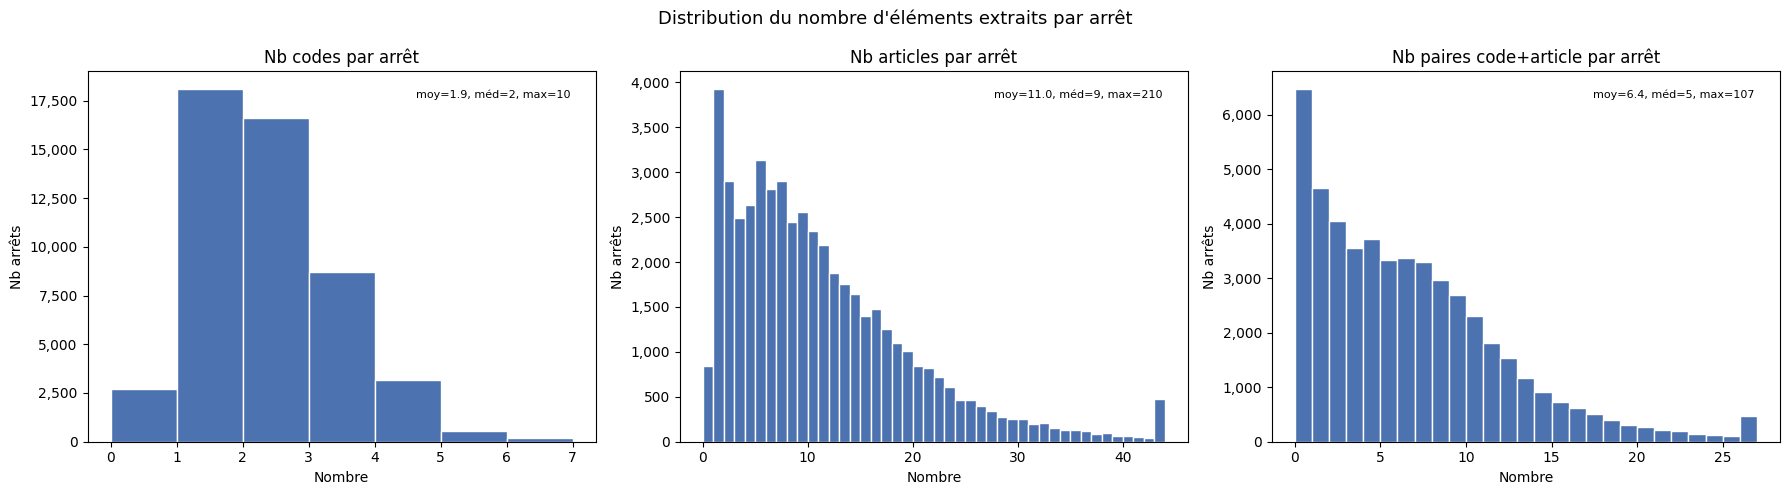

In [22]:
# ── Stats de couverture ─────────────────────────────────────────────────────
print("=" * 60)
print("COUVERTURE")
print("=" * 60)

n_with_code = (df_meta["n_codes"] > 0).sum()
n_with_article = (df_meta["n_articles"] > 0).sum()
n_with_pair = (df_meta["n_pairs"] > 0).sum()
n_nothing = ((df_meta["n_codes"] == 0) & (df_meta["n_articles"] == 0) & (df_meta["n_pairs"] == 0)).sum()

for label, val in [
    ("Arrêts avec ≥1 code", n_with_code),
    ("Arrêts avec ≥1 article", n_with_article),
    ("Arrêts avec ≥1 paire code+article", n_with_pair),
    ("Arrêts sans rien trouvé", n_nothing),
]:
    print(f"  {label:40s}: {val:>7,} ({val/SAMPLE_SIZE*100:.1f}%)")

# ── Distributions ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes, ["n_codes", "n_articles", "n_pairs"],
                           ["Nb codes par arrêt", "Nb articles par arrêt", "Nb paires code+article par arrêt"]):
    data = df_meta[col]
    cap = int(data.quantile(0.99)) + 1
    ax.hist(data.clip(upper=cap), bins=range(0, cap + 2), color="#4C72B0", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Nombre")
    ax.set_ylabel("Nb arrêts")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    stats_txt = f"moy={data.mean():.1f}, méd={data.median():.0f}, max={data.max():.0f}"
    ax.text(0.95, 0.95, stats_txt, transform=ax.transAxes, ha="right", va="top", fontsize=8)

plt.suptitle("Distribution du nombre d'éléments extraits par arrêt", fontsize=13)
plt.tight_layout()
plt.show()

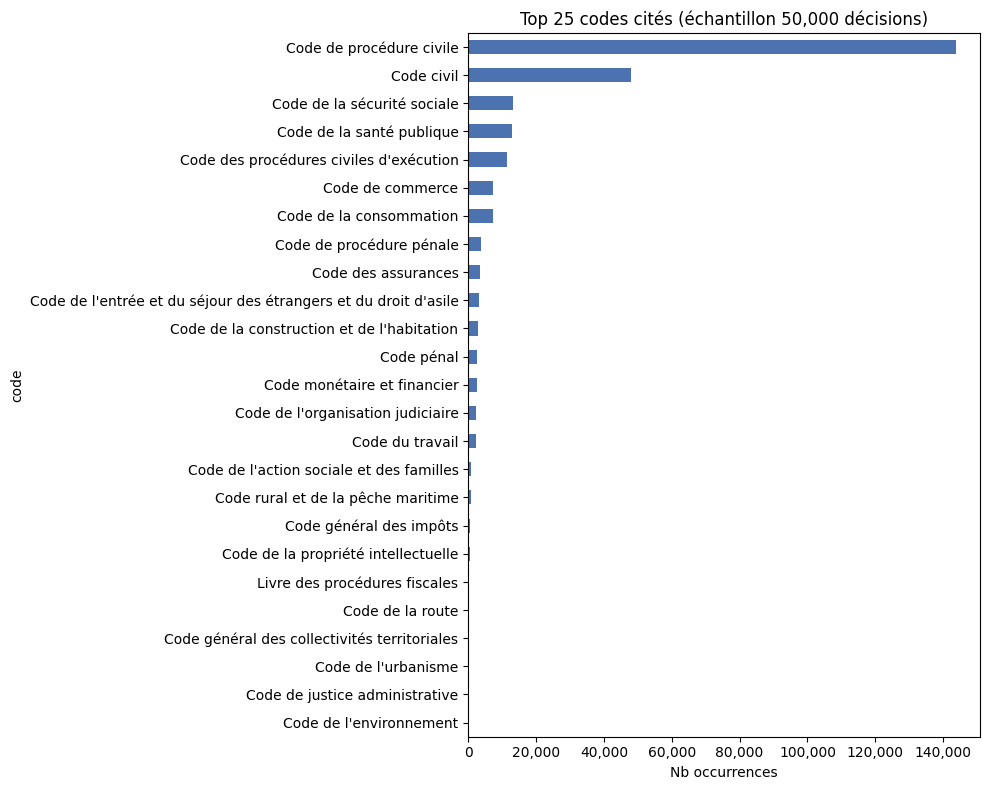

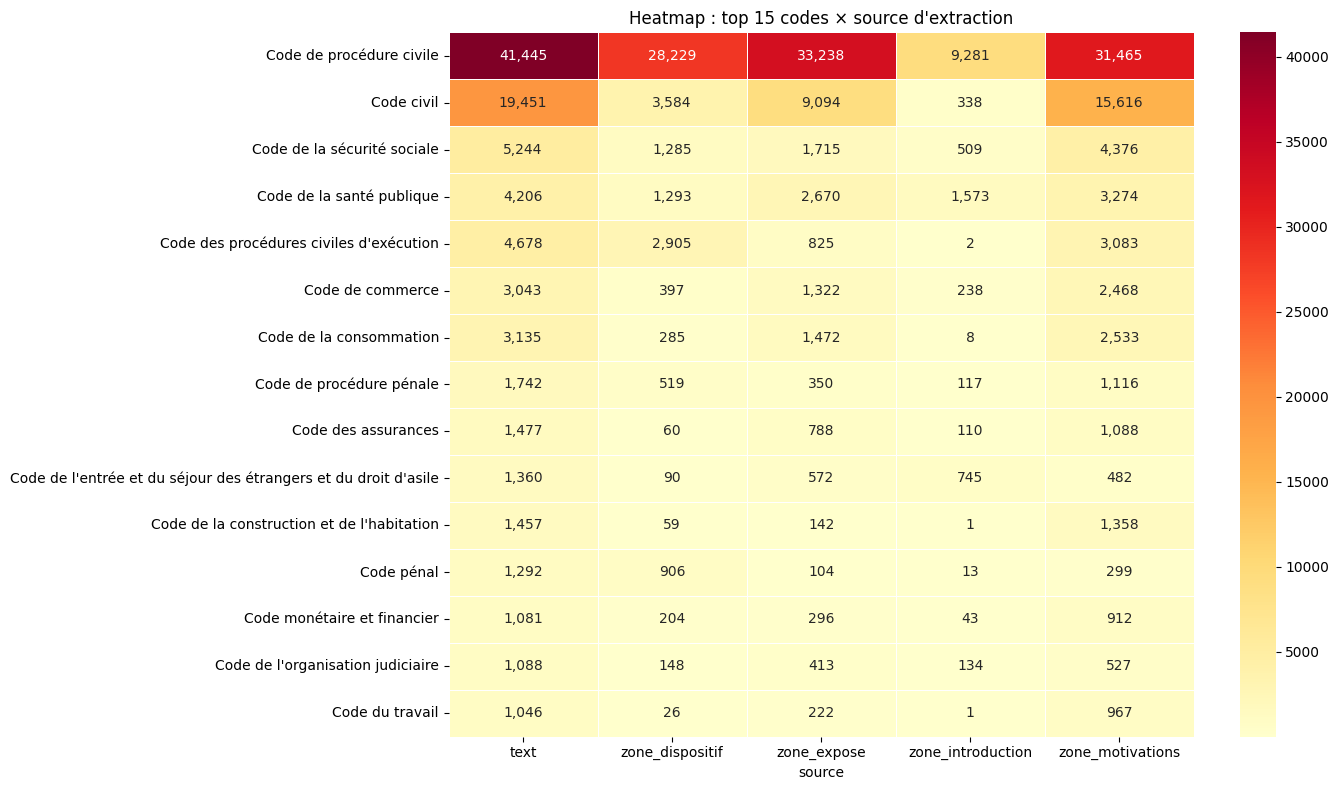

In [23]:
# ── Top codes cités (global) ────────────────────────────────────────────────
import seaborn as sns

top_codes = df_codes["code"].value_counts().head(25)

fig, ax = plt.subplots(figsize=(10, 8))
top_codes[::-1].plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("Nb occurrences")
ax.set_title(f"Top 25 codes cités (échantillon {SAMPLE_SIZE:,} décisions)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

# ── Heatmap codes × source (zone) ──────────────────────────────────────────
top15 = df_codes["code"].value_counts().head(15).index.tolist()
df_codes_top = df_codes[df_codes["code"].isin(top15)]

pivot = df_codes_top.pivot_table(index="code", columns="source", aggfunc="size", fill_value=0)
pivot = pivot.loc[top15]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt=",", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Heatmap : top 15 codes × source d'extraction")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

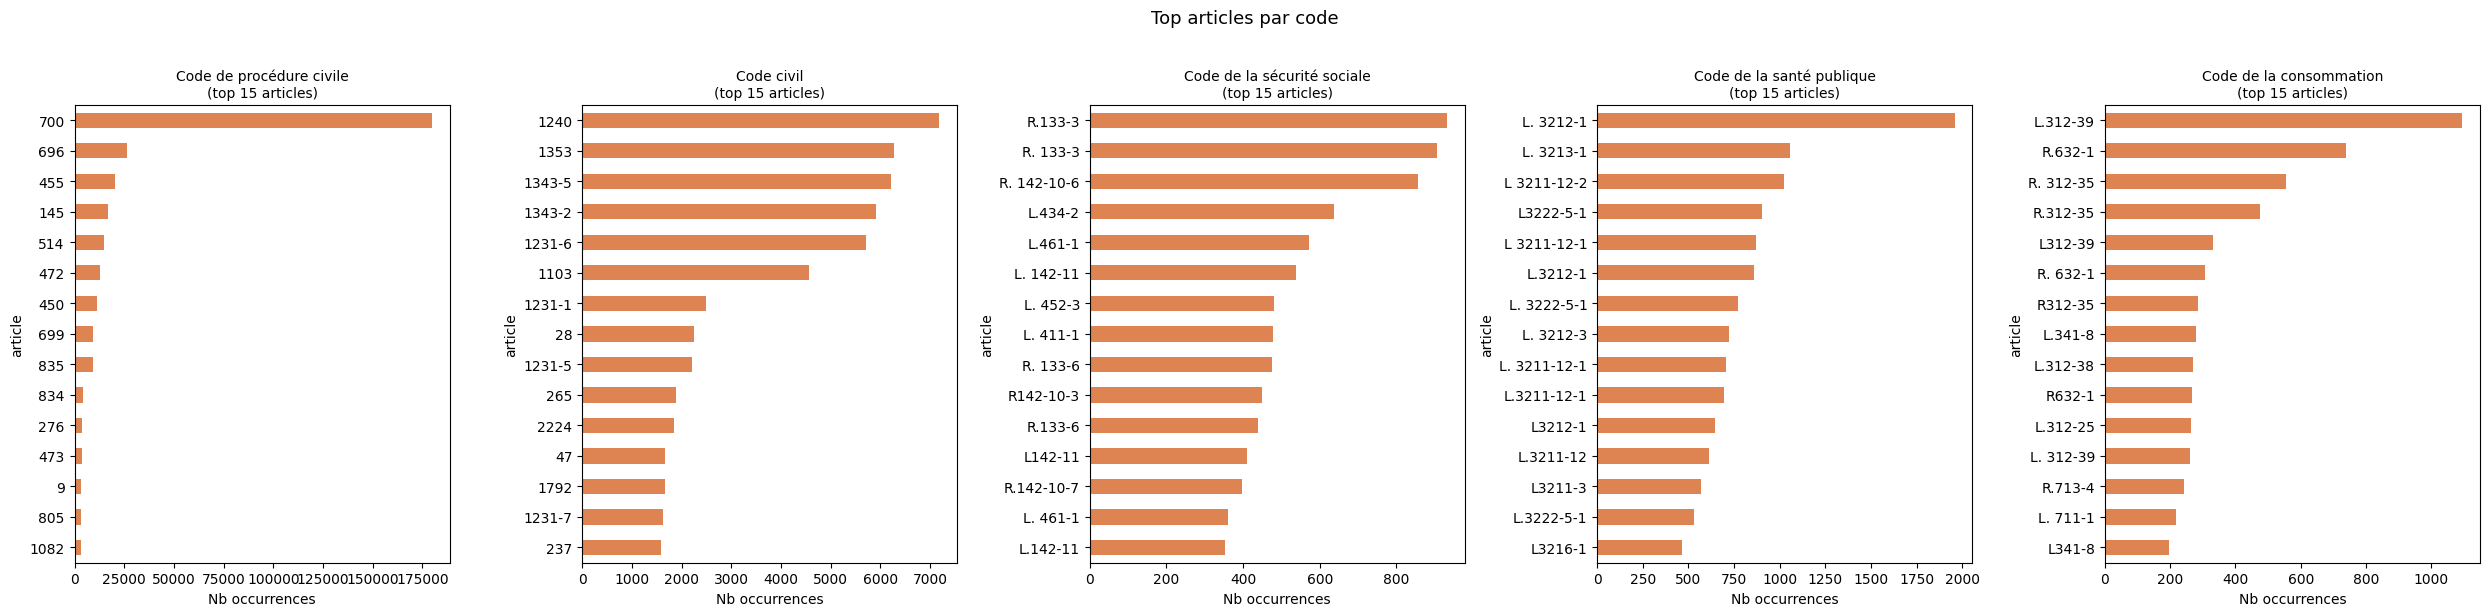

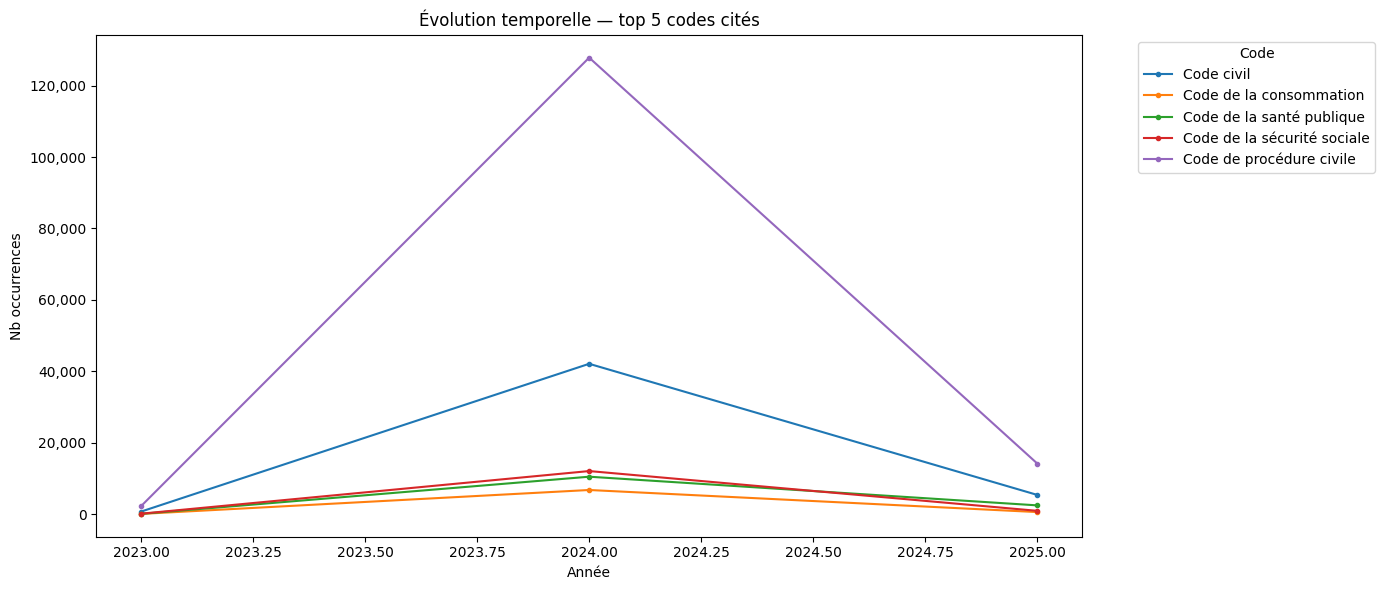

In [24]:
# ── Top articles par code (top 5 codes) ─────────────────────────────────────
top5_codes = df_pairs["code"].value_counts().head(5).index.tolist()

fig, axes = plt.subplots(1, len(top5_codes), figsize=(5 * len(top5_codes), 6))
if len(top5_codes) == 1:
    axes = [axes]

for ax, code_name in zip(axes, top5_codes):
    sub = df_pairs[df_pairs["code"] == code_name]
    top_articles = sub["article"].value_counts().head(15)
    top_articles[::-1].plot.barh(ax=ax, color="#DD8452")
    ax.set_title(f"{code_name}\n(top 15 articles)", fontsize=10)
    ax.set_xlabel("Nb occurrences")

plt.suptitle("Top articles par code", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Évolution temporelle des top 5 codes ────────────────────────────────────
df_codes_year = df_codes.merge(df_meta[["decision_id", "year"]], on="decision_id")
df_codes_year = df_codes_year[df_codes_year["code"].isin(top5_codes) & df_codes_year["year"].notna()]

pivot_year = df_codes_year.pivot_table(index="year", columns="code", aggfunc="size", fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot_year.plot(ax=ax, marker=".", linewidth=1.5)
ax.set_title("Évolution temporelle — top 5 codes cités")
ax.set_xlabel("Année")
ax.set_ylabel("Nb occurrences")
ax.legend(title="Code", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

/var/folders/zz/y6p01ncd2z9_ty6kfx1zk1mh0000gn/T/ipykernel_26408/2158002961.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


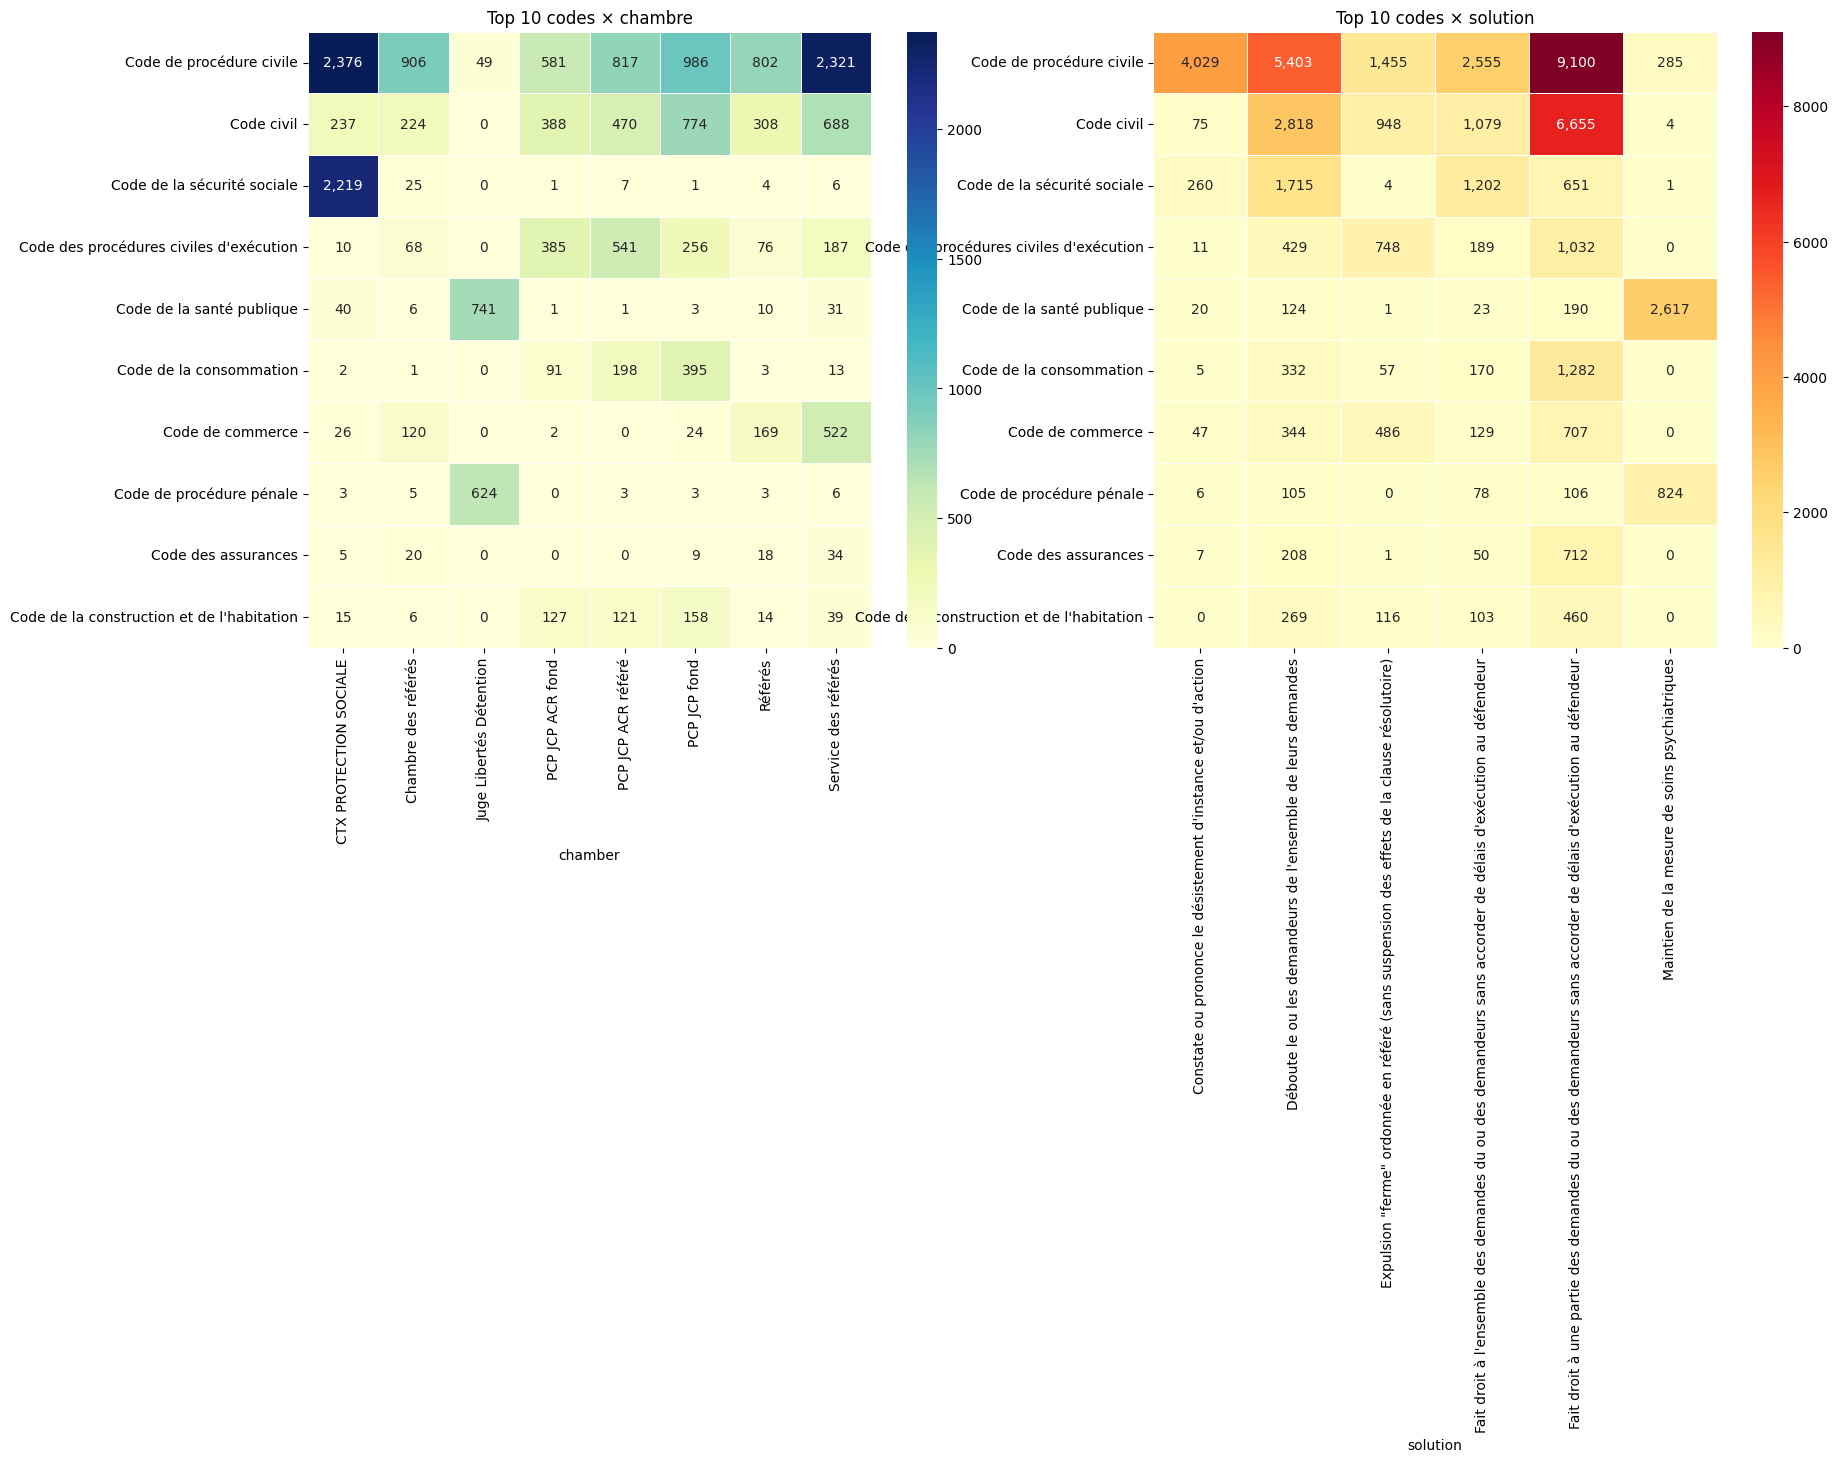

In [25]:
# ── Codes × chambre ─────────────────────────────────────────────────────────
df_codes_meta = df_codes[df_codes["source"] == "text"].merge(
    df_meta[["decision_id", "chamber", "solution"]], on="decision_id"
)

top10_codes = df_codes_meta["code"].value_counts().head(10).index.tolist()
top_chambers = df_codes_meta["chamber"].value_counts().head(8).index.tolist()

df_sub = df_codes_meta[df_codes_meta["code"].isin(top10_codes) & df_codes_meta["chamber"].isin(top_chambers)]
pivot_ch = df_sub.pivot_table(index="code", columns="chamber", aggfunc="size", fill_value=0)
pivot_ch = pivot_ch.loc[[c for c in top10_codes if c in pivot_ch.index]]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(pivot_ch, annot=True, fmt=",", cmap="YlGnBu", ax=axes[0], linewidths=0.5)
axes[0].set_title("Top 10 codes × chambre")
axes[0].set_ylabel("")

# ── Codes × solution ────────────────────────────────────────────────────────
top_solutions = df_codes_meta["solution"].value_counts().head(6).index.tolist()
df_sub2 = df_codes_meta[df_codes_meta["code"].isin(top10_codes) & df_codes_meta["solution"].isin(top_solutions)]
pivot_sol = df_sub2.pivot_table(index="code", columns="solution", aggfunc="size", fill_value=0)
pivot_sol = pivot_sol.loc[[c for c in top10_codes if c in pivot_sol.index]]

sns.heatmap(pivot_sol, annot=True, fmt=",", cmap="YlOrRd", ax=axes[1], linewidths=0.5)
axes[1].set_title("Top 10 codes × solution")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Synthèse extraction codes & articles

In [26]:
# ── Récapitulatif ───────────────────────────────────────────────────────────
print("=" * 60)
print(f"RÉCAPITULATIF — Échantillon de {SAMPLE_SIZE:,} décisions")
print("=" * 60)
print(f"\nCodes distincts trouvés : {df_codes['code'].nunique()}")
print(f"Articles distincts      : {df_articles['number'].nunique()}")
print(f"Paires code+article     : {df_pairs.drop_duplicates(['code','article']).shape[0]}")
print(f"\nCouverture :")
print(f"  Avec code    : {(df_meta['n_codes']>0).mean()*100:.1f}%")
print(f"  Avec article : {(df_meta['n_articles']>0).mean()*100:.1f}%")
print(f"  Avec paire   : {(df_meta['n_pairs']>0).mean()*100:.1f}%")
print(f"  Sans rien    : {((df_meta['n_codes']==0)&(df_meta['n_articles']==0)).mean()*100:.1f}%")

# Top 10 codes
print(f"\nTop 10 codes :")
for code, count in df_codes["code"].value_counts().head(10).items():
    print(f"  {code:50s} {count:>6,}")

RÉCAPITULATIF — Échantillon de 50,000 décisions

Codes distincts trouvés : 52
Articles distincts      : 7193
Paires code+article     : 9378

Couverture :
  Avec code    : 94.6%
  Avec article : 98.3%
  Avec paire   : 87.0%
  Sans rien    : 1.6%

Top 10 codes :
  Code de procédure civile                           143,658
  Code civil                                         48,083
  Code de la sécurité sociale                        13,129
  Code de la santé publique                          13,016
  Code des procédures civiles d'exécution            11,493
  Code de commerce                                    7,468
  Code de la consommation                             7,433
  Code de procédure pénale                            3,844
  Code des assurances                                 3,523
  Code de l'entrée et du séjour des étrangers et du droit d'asile  3,249


### Analyse des arrêts sans code / sans article détecté

Quels champs (`type`, `solution`, `publication`) caractérisent les décisions où l'on ne trouve rien ?
Cela permet d'identifier les décisions "non pertinentes" (procédurales, irrecevabilités, etc.).


  TYPE
       total  with_code  no_code  % sans code  with_article  no_article  % sans article
type                                                                                   
Autre  50000      47299     2701          5.4         49157         843             1.7

  SOLUTION
                                                                                                            total  with_code  no_code  % sans code  with_article  no_article  % sans article
solution                                                                                                                                                                                    
Fait droit à une partie des demandes du ou des demandeurs sans accorder de délais d'exécution au défendeur   9229       9143       86          0.9          9164          65             0.7
Déboute le ou les demandeurs de l'ensemble de leurs demandes                                                 5861       5760      101          1.7   

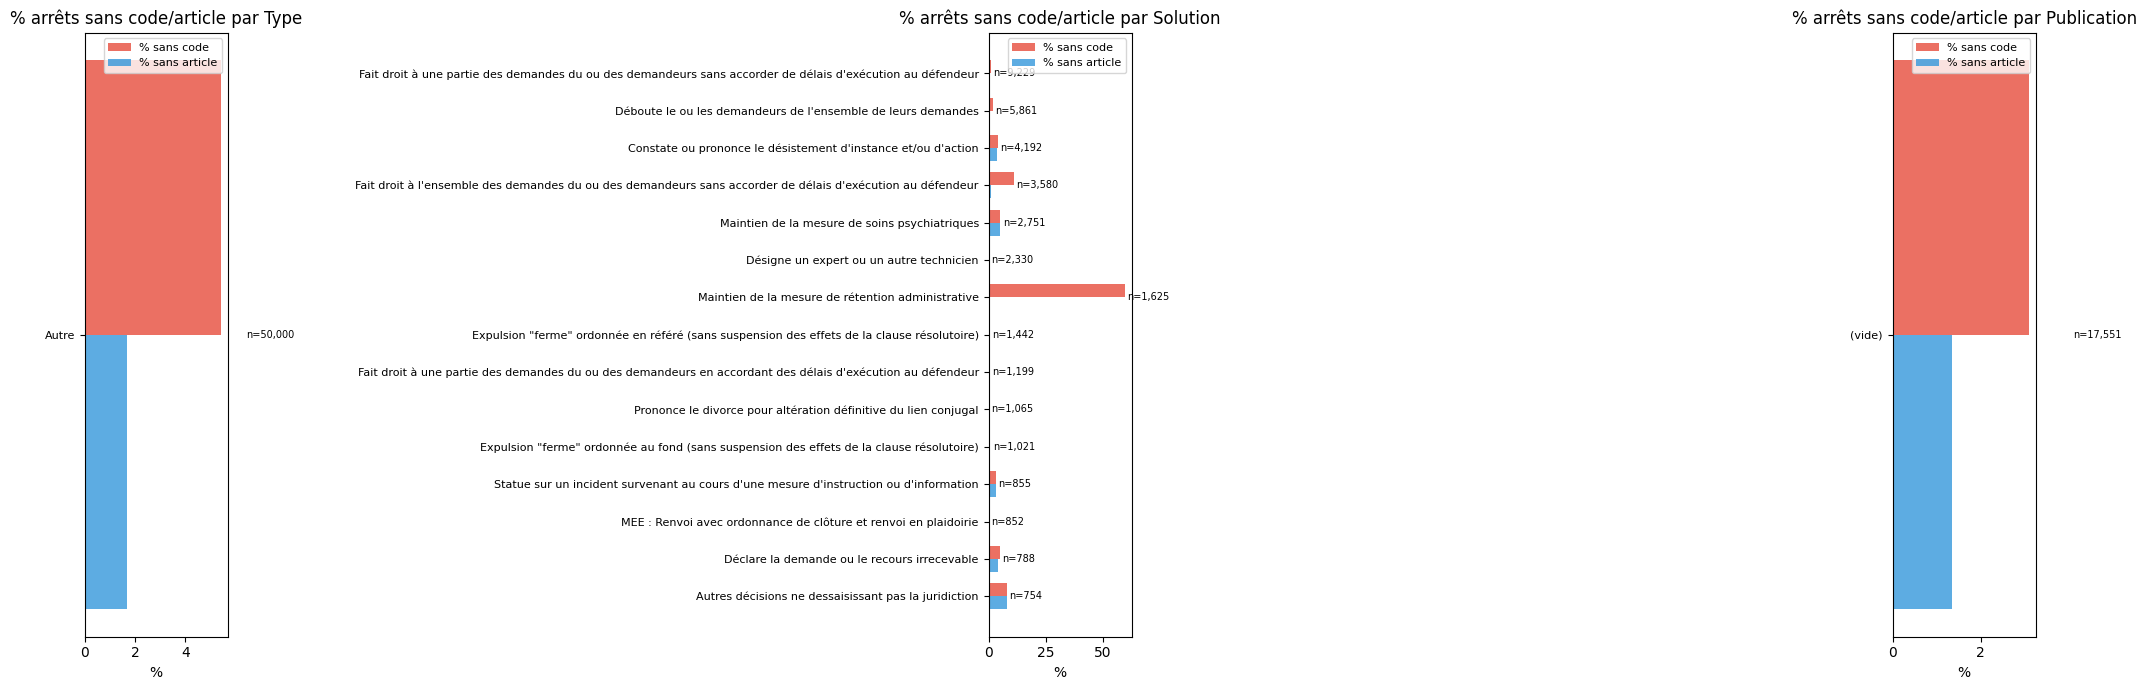


── Solutions avec >50% d'arrêts sans code (n≥50) ──

  Redistribution à une autre chambre        n=    59  sans code=89.8%  sans article=89.8%
  Saisie immobilière - Adjuge le bien à un enchérisseur  n=    72  sans code=69.4%  sans article=13.9%
  Mainlevée de la mesure de rétention administrative  n=   383  sans code=62.9%  sans article=0.0%
  Maintien de la mesure de rétention administrative  n= 1,625  sans code=59.5%  sans article=0.0%


In [27]:
# ── Caractérisation des arrêts avec/sans code et article ────────────────────
# On ajoute les colonnes publication au df_meta via une passe rapide
pub_map = {}
for i, rec in enumerate(iter_records(FILE_PATH, max_records=SAMPLE_SIZE)):
    did = rec.get("id", str(i))
    pub = rec.get("publication", [])
    pub_map[did] = ", ".join(pub) if isinstance(pub, list) and pub else "(vide)"

df_meta["publication"] = df_meta["decision_id"].map(pub_map)
df_meta["has_code"] = df_meta["n_codes"] > 0
df_meta["has_article"] = df_meta["n_articles"] > 0
df_meta["has_pair"] = df_meta["n_pairs"] > 0

# ── Tableau croisé pour type, solution, publication ─────────────────────────
for field in ["type", "solution", "publication"]:
    grp = df_meta.groupby(field).agg(
        total=("has_code", "count"),
        with_code=("has_code", "sum"),
        with_article=("has_article", "sum"),
        with_pair=("has_pair", "sum"),
    ).sort_values("total", ascending=False)

    grp["no_code"] = grp["total"] - grp["with_code"]
    grp["no_article"] = grp["total"] - grp["with_article"]
    grp["% sans code"] = (grp["no_code"] / grp["total"] * 100).round(1)
    grp["% sans article"] = (grp["no_article"] / grp["total"] * 100).round(1)

    print(f"\n{'='*100}")
    print(f"  {field.upper()}")
    print(f"{'='*100}")
    display_cols = ["total", "with_code", "no_code", "% sans code", "with_article", "no_article", "% sans article"]
    print(grp[display_cols].head(20).to_string())

# ── Visualisation : taux "sans code" par solution et par type ───────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, field, title in zip(axes, ["type", "solution", "publication"],
                             ["Type", "Solution", "Publication"]):
    grp = df_meta.groupby(field).agg(
        total=("has_code", "count"),
        pct_no_code=("has_code", lambda x: (1 - x.mean()) * 100),
        pct_no_article=("has_article", lambda x: (1 - x.mean()) * 100),
    ).sort_values("total", ascending=False).head(15)

    x_pos = range(len(grp))
    w = 0.35
    ax.barh([i - w/2 for i in x_pos], grp["pct_no_code"], height=w,
            color="#e74c3c", label="% sans code", alpha=0.8)
    ax.barh([i + w/2 for i in x_pos], grp["pct_no_article"], height=w,
            color="#3498db", label="% sans article", alpha=0.8)
    ax.set_yticks(list(x_pos))
    ax.set_yticklabels(grp.index, fontsize=8)
    ax.set_xlabel("%")
    ax.set_title(f"% arrêts sans code/article par {title}")
    ax.legend(fontsize=8)
    ax.invert_yaxis()

    # Annotations nb total
    for i, (idx, row) in enumerate(grp.iterrows()):
        ax.text(max(row["pct_no_code"], row["pct_no_article"]) + 1, i,
                f"n={int(row['total']):,}", fontsize=7, va="center")

plt.tight_layout()
plt.show()

# ── Focus : quels sont les types de "solution" qui n'ont JAMAIS de code ? ──
print("\n── Solutions avec >50% d'arrêts sans code (n≥50) ──\n")
grp_sol = df_meta.groupby("solution").agg(
    total=("has_code", "count"),
    pct_no_code=("has_code", lambda x: (1 - x.mean()) * 100),
    pct_no_article=("has_article", lambda x: (1 - x.mean()) * 100),
)
grp_sol = grp_sol[grp_sol["total"] >= 50].sort_values("pct_no_code", ascending=False)
for idx, row in grp_sol.iterrows():
    if row["pct_no_code"] > 50:
        print(f"  {idx:40s}  n={int(row['total']):>6,}  sans code={row['pct_no_code']:.1f}%  sans article={row['pct_no_article']:.1f}%")

### Inspection des cas divergents pour améliorer le parsing

- **Code SANS article** : on détecte un code mais aucun article → est-ce normal ou un défaut du parser ?
- **Article SANS code** : on détecte un article mais pas de code → le texte cite-t-il un code qu'on ne parse pas ?

In [28]:
# ── Inspection : code SANS article & article SANS code ──────────────────────

print(f"Code SANS article  : {(df_meta['category'] == 'code SANS article').sum():,} arrêts")
print(f"Article SANS code  : {(df_meta['category'] == 'article SANS code').sum():,} arrêts")

# Filtrer post-2000
for cat_name in ["code SANS article", "article SANS code"]:
    subset = df_meta[(df_meta["category"] == cat_name) & (df_meta["year"].notna()) & (df_meta["year"] >= 2000)]
    print(f"\n  Post-2000 {cat_name}: {len(subset):,}")

# Lire les textes des exemples post-2000 (aléatoire, jusqu'à 5 par catégorie)
target_ids_cna = df_meta[
    (df_meta["category"] == "code SANS article") & (df_meta["year"].notna()) & (df_meta["year"] >= 2000)
]["decision_id"].tolist()[:5]
target_ids_anc = df_meta[
    (df_meta["category"] == "article SANS code") & (df_meta["year"].notna()) & (df_meta["year"] >= 2000)
]["decision_id"].tolist()[:5]

target_ids = set(target_ids_cna + target_ids_anc)
texts_by_id = {}
for i, rec in enumerate(iter_records(FILE_PATH)):
    did = rec.get("id", str(i))
    if did in target_ids:
        texts_by_id[did] = rec.get("text", "")
    if len(texts_by_id) >= len(target_ids):
        break

# ── Affichage : CODE sans article ──────────────────────────────────────────
print("\n" + "=" * 80)
print("  CODE SANS ARTICLE — exemples post-2000")
print("=" * 80)

for did in target_ids_cna[:3]:
    meta_row = df_meta[df_meta["decision_id"] == did].iloc[0]
    codes_found = df_codes[df_codes["decision_id"] == did]["code"].unique().tolist()
    text = texts_by_id.get(did, "(non chargé)")
    print(f"\n{'─'*80}")
    print(f"ID: {did}  |  année: {meta_row['year']:.0f}  |  solution: {meta_row['solution']}  |  type: {meta_row['type']}")
    print(f"Codes détectés: {codes_found}")
    print(f"{'─'*80}")
    print(text[:2500])
    if len(text) > 2500:
        print(f"... [{len(text)} chars total]")

if not target_ids_cna:
    print("  (aucun exemple post-2000 dans l'échantillon)")

# ── Affichage : ARTICLE sans code ──────────────────────────────────────────
print("\n" + "=" * 80)
print("  ARTICLE SANS CODE — exemples post-2000")
print("=" * 80)

for did in target_ids_anc[:3]:
    meta_row = df_meta[df_meta["decision_id"] == did].iloc[0]
    articles_found = df_articles[df_articles["decision_id"] == did][["prefix", "number", "raw"]].drop_duplicates().values.tolist()
    text = texts_by_id.get(did, "(non chargé)")
    print(f"\n{'─'*80}")
    print(f"ID: {did}  |  année: {meta_row['year']:.0f}  |  solution: {meta_row['solution']}  |  type: {meta_row['type']}")
    print(f"Articles détectés: {articles_found}")
    print(f"{'─'*80}")
    print(text[:2500])
    if len(text) > 2500:
        print(f"... [{len(text)} chars total]")

if not target_ids_anc:
    print("  (aucun exemple post-2000 dans l'échantillon)")

KeyError: 'category'